> Proyecto desarrollado dentro de **@PatronesLab** — análisis de datos abiertos con foco en entender el mundo que nos rodea.


# Pasajeros en escala — Baleares (2024–2025)

## 📌 Fuente de datos y consideraciones

Los datos utilizados en este notebook provienen de **AENA – Estadísticas de tráfico aeroportuario**, publicados como datos abiertos a través del portal oficial de AENA (https://www.aena.es/es/estadisticas/inicio.html).

El análisis se centra en los aeropuertos de **Palma de Mallorca, Ibiza y Menorca**, considerados como `aeropuertos_base` según la definición oficial de AENA.

Se respetan estrictamente las definiciones de AENA:
- **Aeropuerto base**: aeropuerto de referencia estadística.
- **Aeropuerto escala**: aeropuerto en el que el pasajero embarca o desembarca.
- **Movimiento**:
  - `LLEGADA`: vuelo que llega al aeropuerto base desde una escala.
  - `SALIDA`: vuelo que parte del aeropuerto base hacia una escala.
- **Pasajeros_totales**: suma de pasajeros y tránsitos.

Todas las métricas de pasajeros se calculan exclusivamente con `pasajeros_totales`.

### Consideraciones metodológicas
- Los datos no permiten identificar el origen o destino final del pasajero cuando existen escalas; el análisis se interpreta como tráfico observado en los aeropuertos base.
- No se filtra ningún registro por tipo de servicio o clase de tráfico, para preservar la integridad estadística.
- Se eliminaron únicamente registros sin actividad real (valores cero en todas las métricas operativas).
- El campo `Mes` fue normalizado a fecha (`YYYY-MM-01`) para permitir agregaciones temporales consistentes.
- Las visualizaciones geográficas utilizan coordenadas de aeropuertos obtenidas de fuentes open data, con fines exclusivamente visuales.

Este notebook tiene un enfoque descriptivo y exploratorio, orientado a análisis reproducible y comunicación visual.

---


In [247]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import pycountry

def pick_col(df: pd.DataFrame, candidates: list[str]) -> str:
    """Devuelve la primera columna existente dentro de una lista de candidatas."""
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"No encuentro ninguna de estas columnas: {candidates}")

def resolve_first_existing(candidates: list[Path]) -> Path:
    """Devuelve la primera ruta existente en una lista de candidatas."""
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "No se encontró el fichero. Rutas probadas: " + ", ".join(str(p) for p in candidates)
    )

# Parámetros de análisis
BASES_BALEARES = ["PALMA DE MALLORCA", "IBIZA", "MENORCA"]
BASES = BASES_BALEARES
YEARS = [2024, 2025]

# Rutas (se resuelven de forma robusta según el directorio de ejecución)
PATH_DATA = resolve_first_existing([
    Path("../data/Pasajeros-Escala_2024_2025.xlsx"),
    Path("Pasajeros-Escala_2024_2025.xlsx"),
    Path("/mnt/data/Pasajeros-Escala_2024_2025.xlsx"),
])

PATH_LKP = resolve_first_existing([
    Path("../data/lkp_aeropuertos.xlsx"),
])

COLOR_2024 = "#F59E0B"
COLOR_2025 = "#7C3AED"


## 1. Carga y revisión inicial

In [203]:
file_path = PATH_DATA
df = pd.read_excel(file_path, engine="openpyxl")

df.head()


,Año,Aeropuerto Base,Aeropuerto Escala,Clase,Mes,Movimiento,País,Servicio,Tipo Avión,Tipo Tráfico,Kg Correo,Mercancías,Mercancías Totales,Mercancías Tránsito,Pasajeros,Pasajeros Totales,Transitos
0,2025,A CORUÑA,ALBACETE / LOS LLANOS,NACIONAL,Julio de 2025,SALIDA,ESPAÑA,NO REGULAR,DASSAULT FALCON 2000/2000DX,COMERCIAL,0,0,0,0,9,9,0
1,2025,A CORUÑA,AALESUND/VIGRA,SCHENGEN NO UE,Julio de 2025,LLEGADA,NORUEGA,NO REGULAR,CESSNA 500 / 501 / 525 CITATION,COMERCIAL,0,0,0,0,1,1,0
2,2025,A CORUÑA,AGEN/LA GARENNE,UE SCHENGEN,Enero de 2025,LLEGADA,FRANCIA,OTROS SERVICIOS COMERCIAL,GULFSTREAM AEROSPACE G-280,COMERCIAL,0,0,0,0,0,4,4
3,2025,A CORUÑA,MÁLAGA-COSTA DEL SOL,NACIONAL,Diciembre de 2025,LLEGADA,ESPAÑA,REGULAR,AIRBUS A319,COMERCIAL,0,0,0,0,300,300,0
4,2025,A CORUÑA,MÁLAGA-COSTA DEL SOL,NACIONAL,Diciembre de 2025,LLEGADA,ESPAÑA,REGULAR,AIRBUS A320 PASSENGER,COMERCIAL,0,0,0,0,1117,1117,0


In [204]:
df.shape


(425449, 17)

In [205]:
df.columns


Index(['Año', 'Aeropuerto Base', 'Aeropuerto Escala', 'Clase', 'Mes',
       'Movimiento', 'País', 'Servicio', 'Tipo Avión', 'Tipo Tráfico',
       'Kg Correo', 'Mercancías', 'Mercancías Totales', 'Mercancías Tránsito',
       'Pasajeros', 'Pasajeros Totales', 'Transitos'],
      dtype='object')

## 2. Preparación
Normalización de columnas y creación de variables temporales.

In [206]:
df.columns = (df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.head(10)

,año,aeropuerto_base,aeropuerto_escala,clase,mes,movimiento,país,servicio,tipo_avión,tipo_tráfico,kg_correo,mercancías,mercancías_totales,mercancías_tránsito,pasajeros,pasajeros_totales,transitos
0,2025,A CORUÑA,ALBACETE / LOS LLANOS,NACIONAL,Julio de 2025,SALIDA,ESPAÑA,NO REGULAR,DASSAULT FALCON 2000/2000DX,COMERCIAL,0,0,0,0,9,9,0
1,2025,A CORUÑA,AALESUND/VIGRA,SCHENGEN NO UE,Julio de 2025,LLEGADA,NORUEGA,NO REGULAR,CESSNA 500 / 501 / 525 CITATION,COMERCIAL,0,0,0,0,1,1,0
2,2025,A CORUÑA,AGEN/LA GARENNE,UE SCHENGEN,Enero de 2025,LLEGADA,FRANCIA,OTROS SERVICIOS COMERCIAL,GULFSTREAM AEROSPACE G-280,COMERCIAL,0,0,0,0,0,4,4
3,2025,A CORUÑA,MÁLAGA-COSTA DEL SOL,NACIONAL,Diciembre de 2025,LLEGADA,ESPAÑA,REGULAR,AIRBUS A319,COMERCIAL,0,0,0,0,300,300,0
4,2025,A CORUÑA,MÁLAGA-COSTA DEL SOL,NACIONAL,Diciembre de 2025,LLEGADA,ESPAÑA,REGULAR,AIRBUS A320 PASSENGER,COMERCIAL,0,0,0,0,1117,1117,0
5,2025,A CORUÑA,MÁLAGA-COSTA DEL SOL,NACIONAL,Diciembre de 2025,SALIDA,ESPAÑA,REGULAR,AIRBUS A319,COMERCIAL,0,0,0,0,277,277,0
6,2025,A CORUÑA,MÁLAGA-COSTA DEL SOL,NACIONAL,Diciembre de 2025,SALIDA,ESPAÑA,REGULAR,AIRBUS A320 PASSENGER,COMERCIAL,0,0,0,0,1105,1105,0
7,2025,A CORUÑA,MÁLAGA-COSTA DEL SOL,NACIONAL,Noviembre de 2025,LLEGADA,ESPAÑA,REGULAR,AIRBUS A319,COMERCIAL,0,0,0,0,152,152,0
8,2025,A CORUÑA,MÁLAGA-COSTA DEL SOL,NACIONAL,Noviembre de 2025,LLEGADA,ESPAÑA,REGULAR,AIRBUS A320 PASSENGER,COMERCIAL,0,0,0,0,1167,1167,0
9,2025,A CORUÑA,MÁLAGA-COSTA DEL SOL,NACIONAL,Noviembre de 2025,SALIDA,ESPAÑA,NO REGULAR,BOEING B737-400 PASSENGERS,COMERCIAL,0,0,0,0,28,28,0


In [207]:
baleares = [
    "PALMA DE MALLORCA",
    "IBIZA",
    "MENORCA"
]

df_baleares = df[
    df["aeropuerto_base"].isin(baleares)
].copy()

df_baleares.shape


(76674, 17)

In [208]:
df_baleares.head(10)

,año,aeropuerto_base,aeropuerto_escala,clase,mes,movimiento,país,servicio,tipo_avión,tipo_tráfico,kg_correo,mercancías,mercancías_totales,mercancías_tránsito,pasajeros,pasajeros_totales,transitos
102044,2025,IBIZA,AALBORG,UE SCHENGEN,Abril de 2025,SALIDA,DINAMARCA,NO REGULAR,"EMBRAER RJ135, LEGANCY 600/650",COMERCIAL,0,0,0,0,5,5,0
102045,2025,IBIZA,AALBORG,UE SCHENGEN,Marzo de 2025,LLEGADA,DINAMARCA,NO REGULAR,CANADAIR CHALLENGER,COMERCIAL,0,0,0,0,5,5,0
102046,2025,IBIZA,AALBORG,UE SCHENGEN,Febrero de 2025,LLEGADA,DINAMARCA,NO REGULAR,"EMBRAER RJ135, LEGANCY 600/650",COMERCIAL,0,0,0,0,1,1,0
102047,2025,IBIZA,AALBORG,UE SCHENGEN,Enero de 2025,SALIDA,DINAMARCA,NO REGULAR,"EMBRAER RJ135, LEGANCY 600/650",COMERCIAL,0,0,0,0,2,2,0
102048,2025,IBIZA,AARHUS/TIRSTRUP,UE SCHENGEN,Septiembre de 2025,SALIDA,DINAMARCA,OTRAS CLASES DE TRAFICO,PIPER (LIGHT AIRCRAFT-SINGLE PISTON),OTRAS CLASES DE TRAFICO,0,0,0,0,2,2,0
102049,2025,IBIZA,AARHUS/TIRSTRUP,UE SCHENGEN,Agosto de 2025,SALIDA,DINAMARCA,NO REGULAR,DASSAULT FALCON 7X,COMERCIAL,0,0,0,0,9,9,0
102050,2025,IBIZA,IBIZA,NACIONAL,Diciembre de 2025,LLEGADA,ESPAÑA,OTRAS CLASES DE TRAFICO,AEROSPATIALE ATR-72,OTRAS CLASES DE TRAFICO,0,0,0,0,59,59,0
102051,2025,IBIZA,ALBACETE / LOS LLANOS,NACIONAL,Septiembre de 2025,LLEGADA,ESPAÑA,OTRAS CLASES DE TRAFICO,SIN CODIGO IATA,OTRAS CLASES DE TRAFICO,0,0,0,0,2,2,0
102052,2025,IBIZA,ALBACETE / LOS LLANOS,NACIONAL,Septiembre de 2025,SALIDA,ESPAÑA,OTRAS CLASES DE TRAFICO,SIN CODIGO IATA,OTRAS CLASES DE TRAFICO,0,0,0,0,6,6,0
102053,2025,IBIZA,ALBACETE / LOS LLANOS,NACIONAL,Agosto de 2025,LLEGADA,ESPAÑA,OTRAS CLASES DE TRAFICO,SIN CODIGO IATA,OTRAS CLASES DE TRAFICO,0,0,0,0,4,4,0


In [209]:
mes_map = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4,
    "mayo": 5, "junio": 6, "julio": 7, "agosto": 8,
    "septiembre": 9, "octubre": 10,
    "noviembre": 11, "diciembre": 12
}

df_baleares["mes_txt"] = df_baleares["mes"].str.lower().str.split(" de ").str[0]
df_baleares["mes_num"] = df_baleares["mes_txt"].map(mes_map)

df_baleares["fecha"] = pd.to_datetime(
    dict(year=df_baleares["año"], month=df_baleares["mes_num"], day=1)
)

df_baleares[["mes", "fecha"]].head(10)


,mes,fecha
102044,Abril de 2025,2025-04-01
102045,Marzo de 2025,2025-03-01
102046,Febrero de 2025,2025-02-01
102047,Enero de 2025,2025-01-01
102048,Septiembre de 2025,2025-09-01
102049,Agosto de 2025,2025-08-01
102050,Diciembre de 2025,2025-12-01
102051,Septiembre de 2025,2025-09-01
102052,Septiembre de 2025,2025-09-01
102053,Agosto de 2025,2025-08-01


## 3. Exploración inicial
Resumenes rápidos para validar volumen y consistencia.

In [210]:
df_baleares.groupby("aeropuerto_base")["pasajeros"].sum().sort_values(ascending=False)


aeropuerto_base
PALMA DE MALLORCA    67085338
IBIZA                18185693
MENORCA               8371057
Name: pasajeros, dtype: int64

In [211]:
df_baleares_llegadas = df_baleares[df_baleares["movimiento"] == "LLEGADA"].copy()

df_baleares_llegadas.shape


(38197, 20)

## 4. Palma de Mallorca
Exploración focalizada para ilustrar ranking de aeropuertos de escala.

In [212]:
df_palma = df_baleares[df_baleares["aeropuerto_base"] == "PALMA DE MALLORCA"]


## 5. Llegadas vs salidas
Comparación por aeropuerto de escala (Top 10).

In [213]:
agg = (
    df_palma
    .groupby(["aeropuerto_escala", "movimiento"], as_index=False)["pasajeros"]
    .sum()
)


In [214]:
pivot = (
    agg
    .pivot(index="aeropuerto_escala", columns="movimiento", values="pasajeros")
    .fillna(0)
)


In [215]:
pivot["total"] = pivot["LLEGADA"] + pivot["SALIDA"]

top10 = (
    pivot
    .sort_values("total", ascending=False)
    .head(10)
    .sort_values("total", ascending=True)  # para que quede estético
)


In [216]:
llegadas = -top10["LLEGADA"]
salidas = top10["SALIDA"]
labels = top10.index


### Visualización
Gráfico generado a partir del agregado definido en las celdas anteriores.

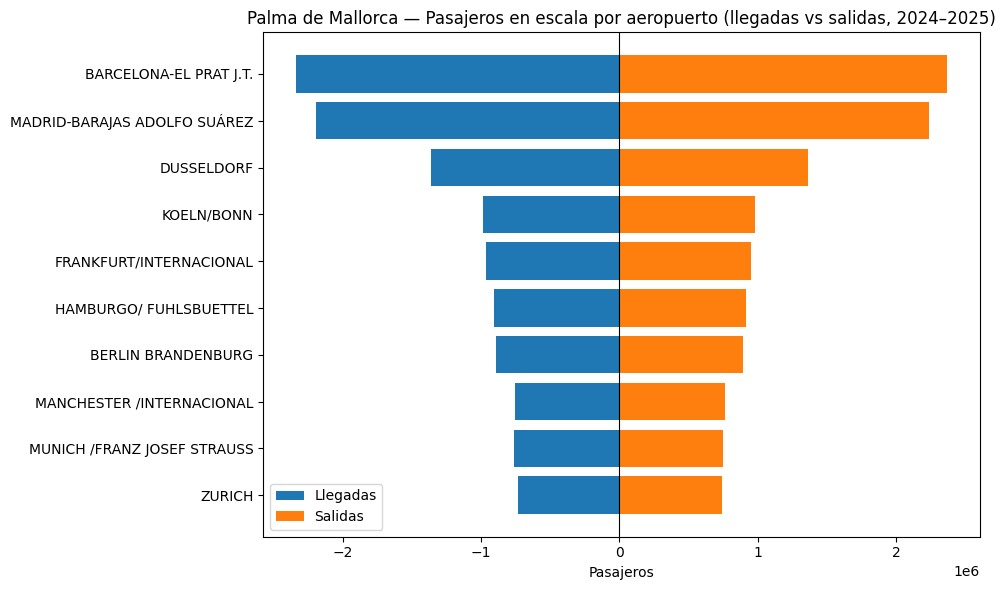

In [217]:
plt.figure(figsize=(10, 6))

plt.barh(labels, llegadas, label="Llegadas")
plt.barh(labels, salidas, label="Salidas")

plt.axvline(0, color="black", linewidth=0.8)

plt.title("Palma de Mallorca — Pasajeros en escala por aeropuerto (llegadas vs salidas, 2024–2025)")
plt.xlabel("Pasajeros")
plt.ylabel("")

plt.legend()
plt.tight_layout()
plt.show()


## 6. Visualizaciones interactivas
Gráficos con Plotly para explorar Top N y comparativas.

### Visualización
Gráfico generado a partir del agregado definido en las celdas anteriores.

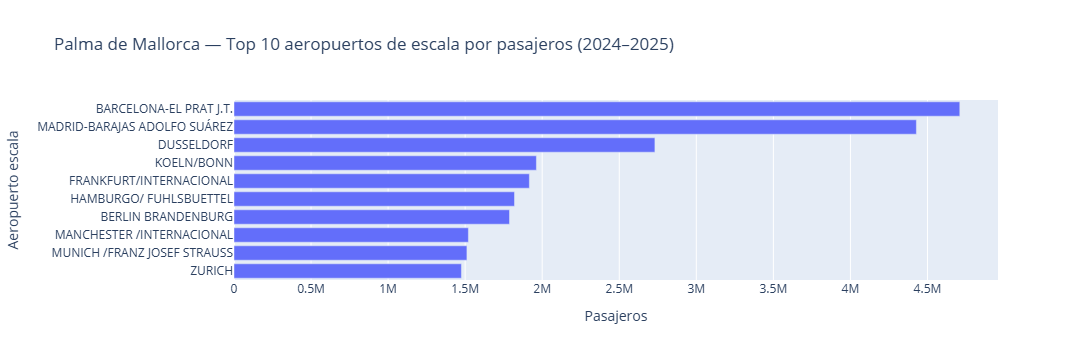

In [218]:
fig = px.bar(
    top10.reset_index(),
    x="total",
    y="aeropuerto_escala",
    orientation="h",
    title="Palma de Mallorca — Top 10 aeropuertos de escala por pasajeros (2024–2025)",
    labels={"total": "Pasajeros", "aeropuerto_escala": "Aeropuerto escala"},
)

fig.show()

### Comparación — llegadas vs salidas (Palma de Mallorca)
Gráfico espejo por aeropuerto de escala (Top 10).

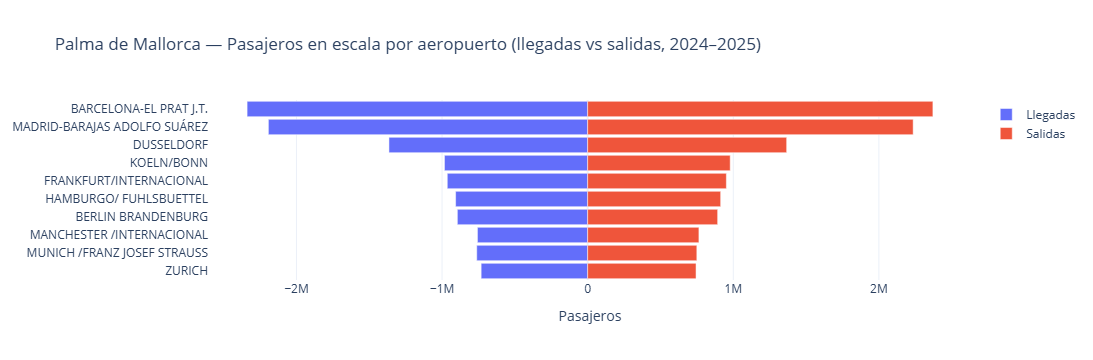

In [219]:
fig = go.Figure()

fig.add_trace(
    go.Bar(
        y=labels,
        x=llegadas,
        orientation="h",
        name="Llegadas",
        hovertemplate="Llegadas: %{x:.0f}<extra></extra>",
    )
)

fig.add_trace(
    go.Bar(
        y=labels,
        x=salidas,
        orientation="h",
        name="Salidas",
        hovertemplate="Salidas: %{x:.0f}<extra></extra>",
    )
)

fig.update_layout(
    title="Palma de Mallorca — Pasajeros en escala por aeropuerto (llegadas vs salidas, 2024–2025)",
    xaxis_title="Pasajeros",
    barmode="relative",
    bargap=0.15,
    template="plotly_white",
)

fig.show()


### 6.1 Top aeropuertos de escala por año
Separado por movimiento (llegadas/salidas).

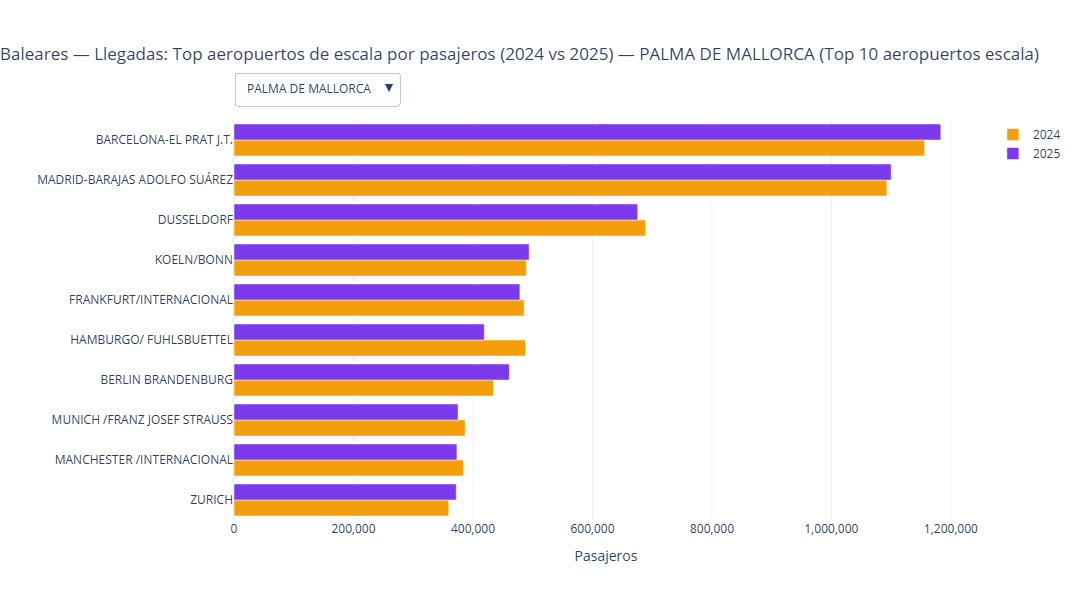

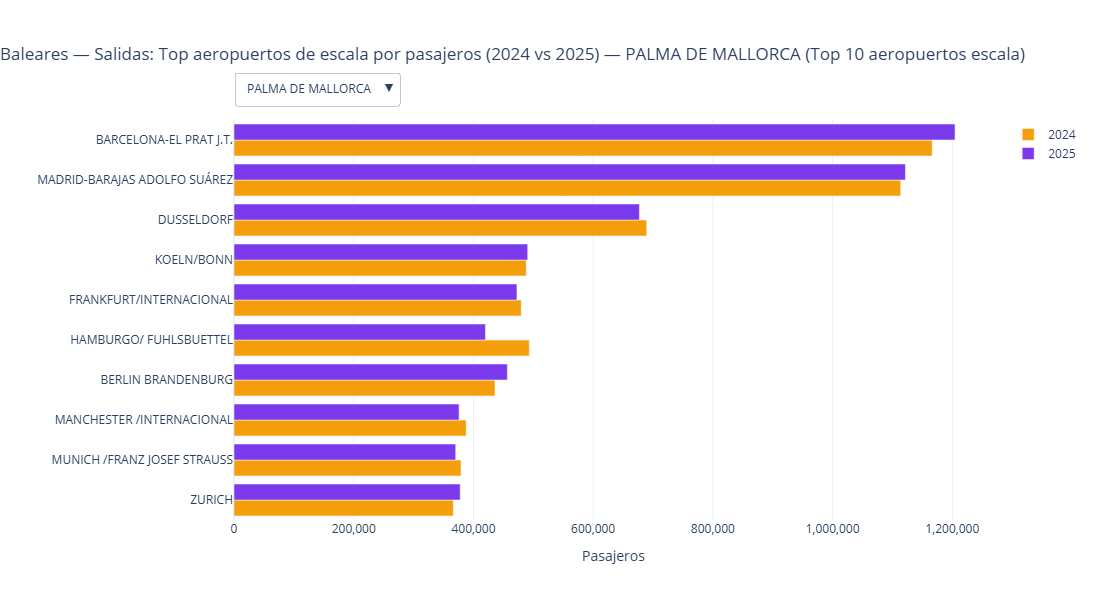

In [221]:
def compute_top10_by_base_movement_year(df_baleares, base, movement, top_n=10, years=YEARS):
    d = df_baleares[
        (df_baleares["aeropuerto_base"] == base) &
        (df_baleares["movimiento"] == movement)
    ].copy()

    g = (
        d.groupby(["aeropuerto_escala", "año"], as_index=False)["pasajeros"]
         .sum()
    )

    p = (
        g.pivot(index="aeropuerto_escala", columns="año", values="pasajeros")
         .fillna(0)
    )

    for y in years:
        if y not in p.columns:
            p[y] = 0

    p["total"] = p[years].sum(axis=1)

    top = (
        p.sort_values("total", ascending=False)
         .head(top_n)
         .sort_values("total", ascending=True)
    )

    labels = top.index.tolist()
    values_by_year = {y: top[y].tolist() for y in years}

    return labels, values_by_year

def build_figure(df_baleares, movement, title_prefix, top_n=10):
    # Precalcular datos para cada base
    pre = {}
    for b in BASES:
        labels, values_by_year = compute_top10_by_base_movement_year(
            df_baleares, base=b, movement=movement, top_n=top_n, years=YEARS
        )
        pre[b] = (labels, values_by_year)

    # Figura inicial con la primera base
    base0 = BASES[0]
    labels0, vals0 = pre[base0]

    fig = go.Figure()

    # Trazas: una por año
    fig.add_trace(go.Bar(
        y=labels0, x=vals0[2024], orientation="h",
        name="2024", marker_color=COLOR_2024,
        hovertemplate="2024: %{x:,.0f}<extra></extra>"
    ))
    fig.add_trace(go.Bar(
        y=labels0, x=vals0[2025], orientation="h",
        name="2025", marker_color=COLOR_2025,
        hovertemplate="2025: %{x:,.0f}<extra></extra>"
    ))

    # Dropdown para cambiar base
    buttons = []
    for b in BASES:
        labels, vals = pre[b]
        buttons.append(dict(
            label=b,
            method="update",
            args=[
                {"x": [vals[2024], vals[2025]],
                 "y": [labels, labels]},
                {"title.text": f"{title_prefix} — {b} (Top {top_n} aeropuertos escala)"}
            ]
        ))

    fig.update_layout(
        title=dict(
            text=f"{title_prefix} — {base0} (Top {top_n} aeropuertos escala)",
            x=0.0,
            xanchor="left"
        ),
        xaxis_title="Pasajeros",
        yaxis_title="",
        barmode="group",
        template="plotly_white",
        height=600,
        updatemenus=[dict(
            buttons=buttons,
            direction="down",
            x=0.0,
            xanchor="left",
            y=1.12,
            yanchor="top",
            showactive=True
        )],
        margin=dict(t=120)
    )

    fig.update_xaxes(tickformat=",")

    return fig

fig_llegadas = build_figure(
    df_baleares,
    movement="LLEGADA",
    title_prefix="Baleares — Llegadas: Top aeropuertos de escala por pasajeros (2024 vs 2025)",
    top_n=10
)
fig_llegadas.show()

fig_salidas = build_figure(
    df_baleares,
    movement="SALIDA",
    title_prefix="Baleares — Salidas: Top aeropuertos de escala por pasajeros (2024 vs 2025)",
    top_n=10
)
fig_salidas.show()


### 6.2 Top por dimensión
Ranking por país, clase u otras variables (según disponibilidad).

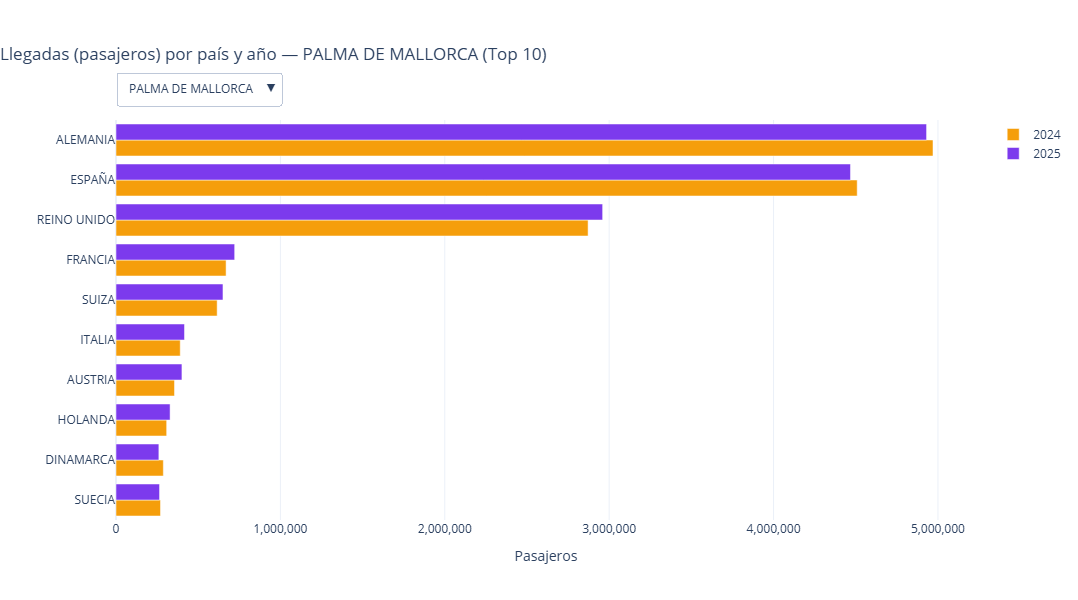

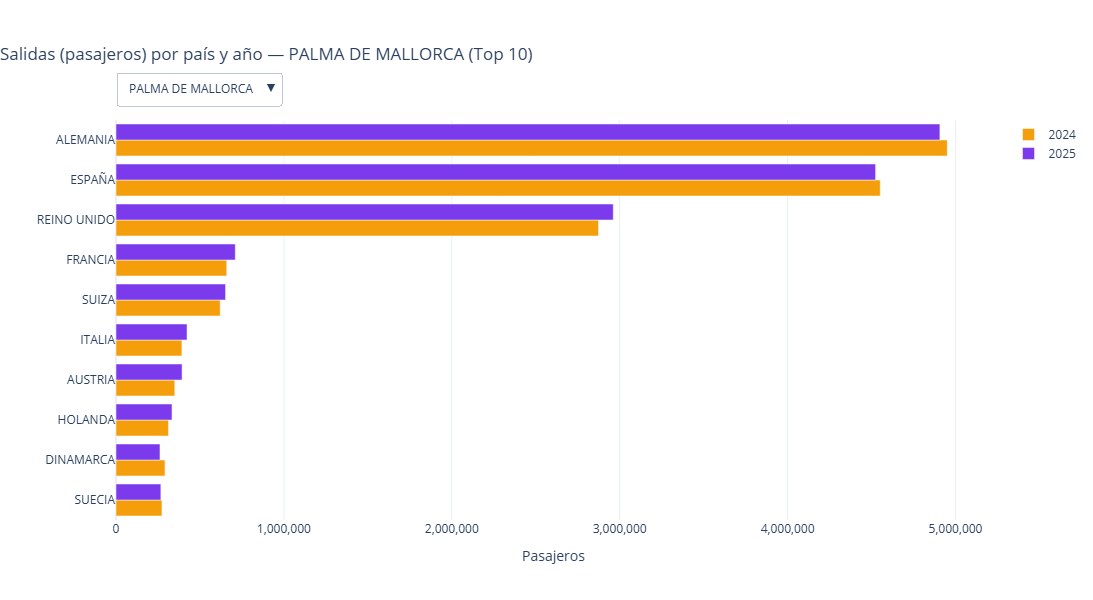

In [222]:
def compute_topN_by_base_movement_year_dim(df_baleares, base, movement, dim_col, top_n=10, years=YEARS):
    d = df_baleares[
        (df_baleares["aeropuerto_base"] == base) &
        (df_baleares["movimiento"] == movement)
    ].copy()

    g = (
        d.groupby([dim_col, "año"], as_index=False)["pasajeros"]
         .sum()
    )

    p = (
        g.pivot(index=dim_col, columns="año", values="pasajeros")
         .fillna(0)
    )

    for y in years:
        if y not in p.columns:
            p[y] = 0

    p["total"] = p[years].sum(axis=1)

    top = (
        p.sort_values("total", ascending=False)
         .head(top_n)
         .sort_values("total", ascending=True)
    )

    labels = top.index.tolist()
    values_by_year = {y: top[y].tolist() for y in years}

    return labels, values_by_year

def build_figure_dim(df_baleares, movement, title_prefix, dim_col, top_n=10):
    pre = {}
    for b in BASES:
        labels, values_by_year = compute_topN_by_base_movement_year_dim(
            df_baleares, base=b, movement=movement, dim_col=dim_col, top_n=top_n, years=YEARS
        )
        pre[b] = (labels, values_by_year)

    base0 = BASES[0]
    labels0, vals0 = pre[base0]

    fig = go.Figure()

    fig.add_trace(go.Bar(
        y=labels0, x=vals0[2024], orientation="h",
        name="2024", marker_color=COLOR_2024,
        hovertemplate="2024: %{x:,.0f}<extra></extra>"
    ))
    fig.add_trace(go.Bar(
        y=labels0, x=vals0[2025], orientation="h",
        name="2025", marker_color=COLOR_2025,
        hovertemplate="2025: %{x:,.0f}<extra></extra>"
    ))

    buttons = []
    for b in BASES:
        labels, vals = pre[b]
        buttons.append(dict(
            label=b,
            method="update",
            args=[
                {"x": [vals[2024], vals[2025]],
                 "y": [labels, labels]},
                {"title.text": f"{title_prefix} — {b} (Top {top_n})"}
            ]
        ))

    fig.update_layout(
        title=dict(
            text=f"{title_prefix} — {base0} (Top {top_n})",
            x=0.0,
            xanchor="left"
        ),
        xaxis_title="Pasajeros",
        yaxis_title="",
        barmode="group",
        template="plotly_white",
        height=600,
        updatemenus=[dict(
            buttons=buttons,
            direction="down",
            x=0.0,
            xanchor="left",
            y=1.12,
            yanchor="top",
            showactive=True
        )],
        margin=dict(t=120)
    )

    fig.update_xaxes(tickformat=",")

    return fig

pais_col = "país" if "país" in df_baleares.columns else "pais"

fig_llegadas_pais = build_figure_dim(
    df_baleares,
    movement="LLEGADA",
    title_prefix="Llegadas (pasajeros) por país y año",
    dim_col=pais_col,
    top_n=10
)
fig_llegadas_pais.show()

fig_salidas_pais = build_figure_dim(
    df_baleares,
    movement="SALIDA",
    title_prefix="Salidas (pasajeros) por país y año",
    dim_col=pais_col,
    top_n=10
)
fig_salidas_pais.show()


### Exploración interactiva — Top 10 por aeropuerto base
Comparación de llegadas vs salidas por aeropuerto de escala, con selector de aeropuerto base.

In [223]:
def compute_top10_country_merch(df, base, movement, top_n=10):
    d = df[
        (df["aeropuerto_base"] == base) &
        (df["movimiento"] == movement) &
        (df["país"] != "ESPAÑA")
    ].copy()

    g = (
        d.groupby(["país", "año"], as_index=False)["mercancías_totales"]
         .sum()
    )

    p = (
        g.pivot(index="país", columns="año", values="mercancías_totales")
         .fillna(0)
    )

    for y in YEARS:
        if y not in p.columns:
            p[y] = 0

    p["total"] = p[YEARS].sum(axis=1)

    top = (
        p.sort_values("total", ascending=False)
         .head(top_n)
         .sort_values("total", ascending=True)
    )

    labels = top.index.tolist()
    values = {y: top[y].tolist() for y in YEARS}

    return labels, values

def build_figure_merch_country(df, movement, title_prefix, top_n=10):
    pre = {}
    for b in BASES:
        pre[b] = compute_top10_country_merch(df, b, movement, top_n)

    base0 = BASES[0]
    labels0, vals0 = pre[base0]

    fig = go.Figure()

    fig.add_bar(
        y=labels0, x=vals0[2024],
        orientation="h",
        name="2024",
        marker_color=COLOR_2024,
        hovertemplate="2024: %{x:,.0f} kg<extra></extra>"
    )

    fig.add_bar(
        y=labels0, x=vals0[2025],
        orientation="h",
        name="2025",
        marker_color=COLOR_2025,
        hovertemplate="2025: %{x:,.0f} kg<extra></extra>"
    )

    buttons = []
    for b in BASES:
        labels, vals = pre[b]
        buttons.append(dict(
            label=b,
            method="update",
            args=[
                {"x": [vals[2024], vals[2025]],
                 "y": [labels, labels]},
                {"title.text": f"{title_prefix} — {b} (Top {top_n})"}
            ]
        ))

    fig.update_layout(
        title=dict(
            text=f"{title_prefix} — {base0} (Top {top_n})",
            x=0.0,
            xanchor="left"
        ),
        xaxis_title="Kg de mercancías totales",
        yaxis_title="",
        barmode="group",
        template="plotly_white",
        height=600,
        updatemenus=[dict(
            buttons=buttons,
            direction="down",
            x=0.0,
            xanchor="left",
            y=1.12,
            yanchor="top",
            showactive=True
        )],
        margin=dict(t=120)
    )

    fig.update_xaxes(tickformat=",")

    return fig


### 6.3 Mercancías
Ranking por país (mercancías totales) por año y movimiento.

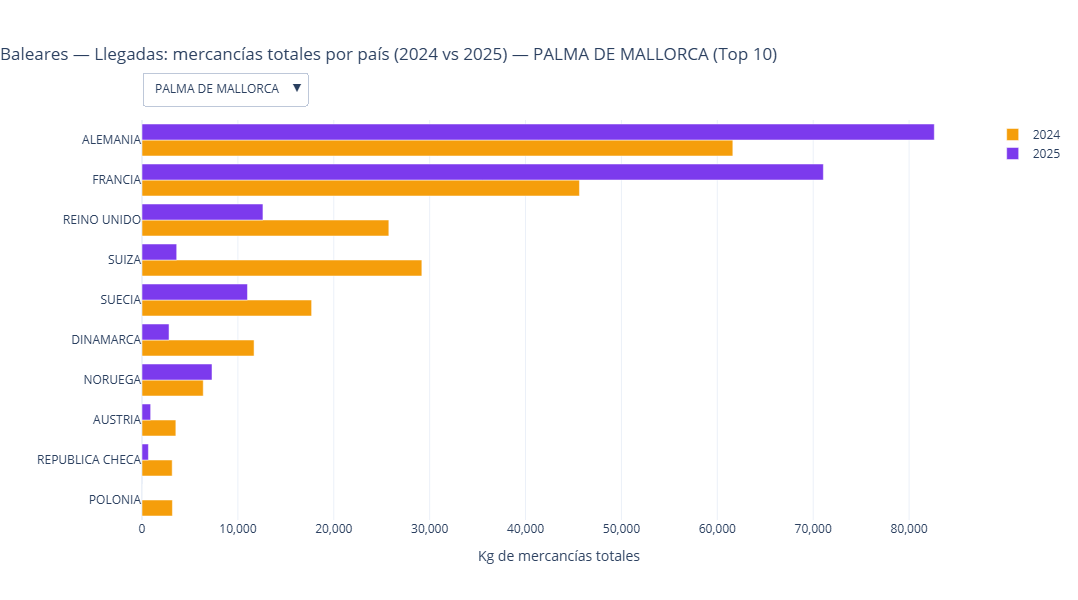

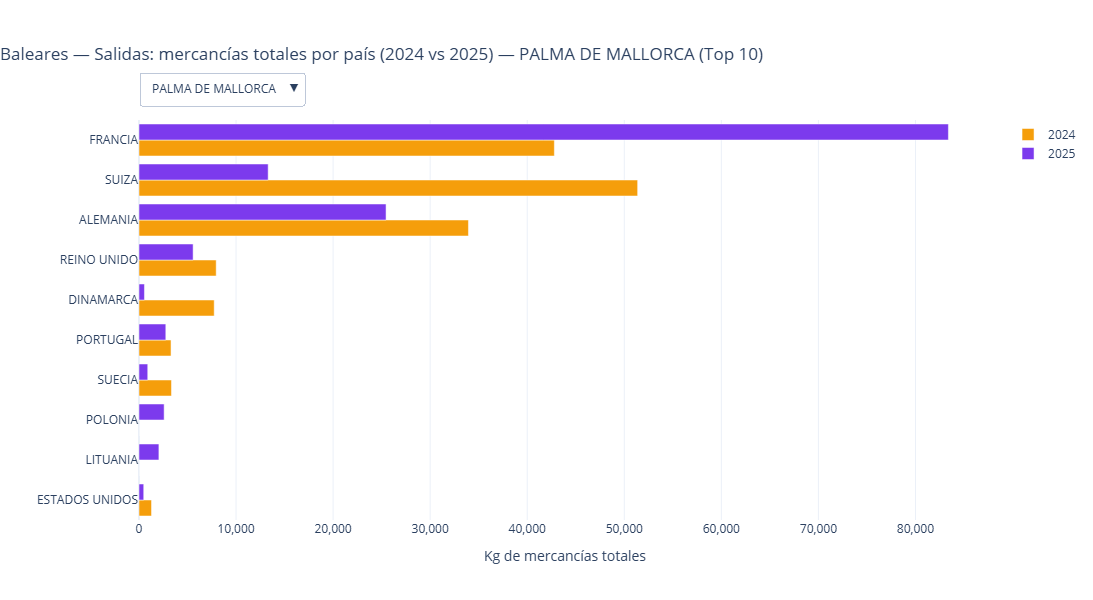

In [224]:
# LLEGADAS
fig_llegadas_merc = build_figure_merch_country(
    df_baleares,
    movement="LLEGADA",
    title_prefix="Baleares — Llegadas: mercancías totales por país (2024 vs 2025)",
    top_n=10
)
fig_llegadas_merc.show()

# SALIDAS
fig_salidas_merc = build_figure_merch_country(
    df_baleares,
    movement="SALIDA",
    title_prefix="Baleares — Salidas: mercancías totales por país (2024 vs 2025)",
    top_n=10
)
fig_salidas_merc.show()


## 7. Series temporales
Evolución mensual de llegadas por país y aeropuerto base.

In [225]:
# Solo llegadas al aeropuerto base
df_ts = (
    df_baleares[df_baleares["movimiento"] == "LLEGADA"]
    .groupby(["fecha", "aeropuerto_base", "país"], as_index=False)["pasajeros"]
    .sum()
)

# Rango mensual completo (relleno de meses faltantes con 0)
all_dates = pd.date_range(df_ts["fecha"].min(), df_ts["fecha"].max(), freq="MS")

# Países del dropdown: Top 20 por volumen (para que sea usable)
top_countries = (
    df_ts.groupby("país")["pasajeros"].sum()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

# top_countries = [c for c in top_countries if c != "ESPAÑA"]


In [226]:
def series_for_country(country: str):
    d = df_ts[df_ts["país"] == country]

    p = (
        d.pivot(index="fecha", columns="aeropuerto_base", values="pasajeros")
         .reindex(all_dates)
         .fillna(0)
    )

    # asegurar las 3 columnas
    for b in BASES:
        if b not in p.columns:
            p[b] = 0

    p = p[BASES]

    x = p.index
    ys = [p[b].values for b in BASES]
    return x, ys


### Serie temporal — evolución mensual por país
Evolución mensual de pasajeros (llegadas) por aeropuerto base, con selector de país.

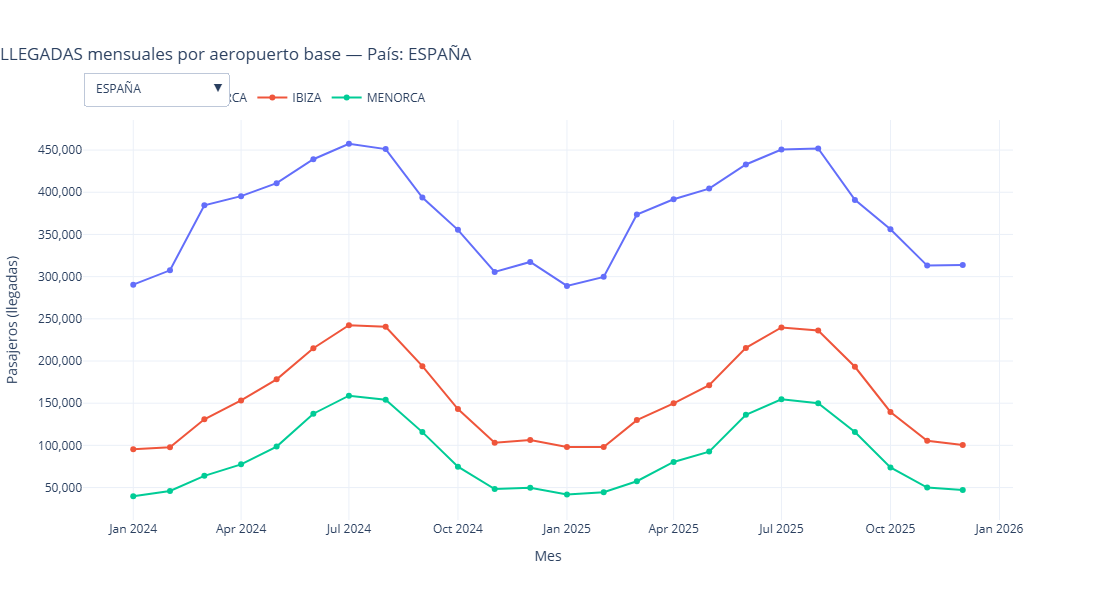

In [227]:
country0 = top_countries[0]
x0, ys0 = series_for_country(country0)

fig = go.Figure()

# 3 líneas: Palma/Ibiza/Menorca
for i, base in enumerate(BASES):
    fig.add_trace(go.Scatter(
        x=x0,
        y=ys0[i],
        mode="lines+markers",
        name=base,
        hovertemplate="%{x|%b %Y}<br>Pasajeros (llegadas): %{y:,.0f}<extra></extra>"
    ))

# Dropdown de países
buttons = []
for c in top_countries:
    x, ys = series_for_country(c)
    buttons.append(dict(
        label=c,
        method="update",
        args=[
            {"x": [x, x, x], "y": ys},
            {"title.text": f"LLEGADAS mensuales por aeropuerto base — País: {c}"}
        ]
    ))

fig.update_layout(
    title=dict(
        text=f"LLEGADAS mensuales por aeropuerto base — País: {country0}",
        x=0.0, xanchor="left"
    ),
    xaxis_title="Mes",
    yaxis_title="Pasajeros (llegadas)",
    template="plotly_white",
    height=600,
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        x=0.0, xanchor="left",
        y=1.12, yanchor="top",
        showactive=True
    )],
    margin=dict(t=120),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0)
)

fig.update_xaxes(tickformat="%b %Y")
fig.update_yaxes(tickformat=",")

fig.show()


In [228]:
# Solo llegadas
d = df_baleares[df_baleares["movimiento"] == "LLEGADA"].copy()

# Agregado mensual por país
ts = (
    d.groupby(["fecha", "país"], as_index=False)["pasajeros"]
     .sum()
)

# Orden temporal + etiqueta mes-año para la animación
ts = ts.sort_values("fecha")
ts["mes_anio"] = ts["fecha"].dt.strftime("%Y-%m")


### 7.1 Top 10 mensual (animación)

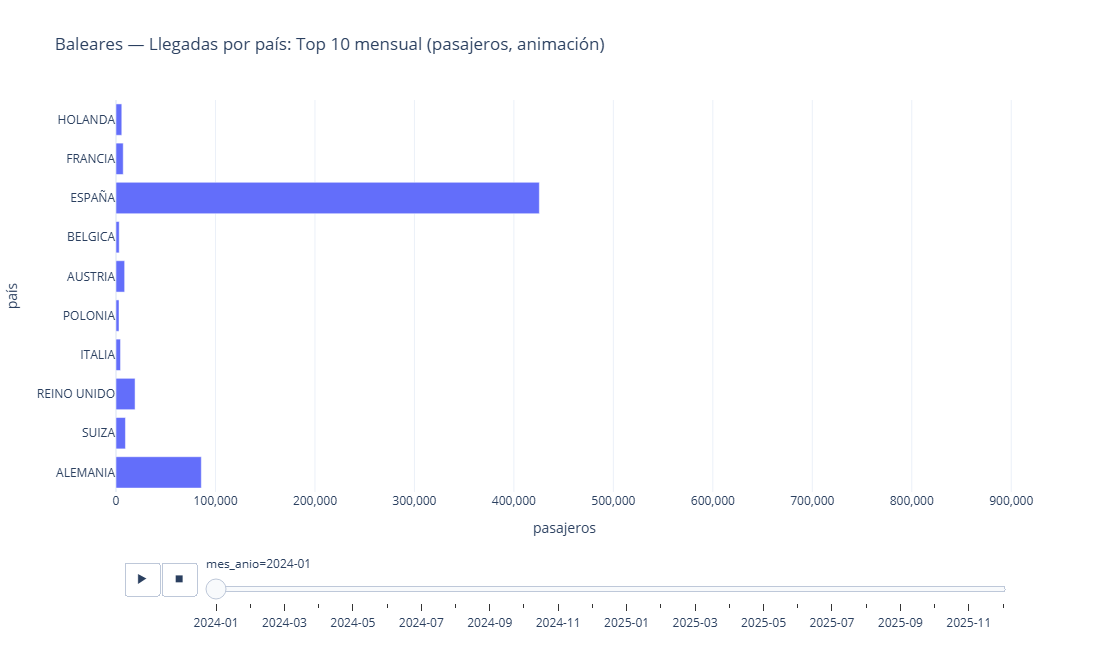

In [229]:
top_n = 10

ts_top = (
    ts.assign(rank=ts.groupby("mes_anio")["pasajeros"].rank(method="first", ascending=False))
      .query("rank <= @top_n")
      .drop(columns="rank")
)

fig = px.bar(
    ts_top,
    x="pasajeros",
    y="país",
    orientation="h",
    animation_frame="mes_anio",
    animation_group="país",
    range_x=[0, ts_top["pasajeros"].max() * 1.05],
    title="Baleares — Llegadas por país: Top 10 mensual (pasajeros, animación)",
)

fig.update_layout(template="plotly_white", height=650)
fig.update_xaxes(tickformat=",")
fig.show()

fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 6000
fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 6000


## 8. Estadísticos descriptivos
Descripción general para control de valores extremos.

In [230]:
df_baleares.describe(
    include="number",
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
).T


,count,mean,std,min,5%,25%,50%,75%,95%,max
año,76674.0,2024.499217,0.500003,2024.0,2024.0,2024.0,2024.0,2025.0,2025.00,2025.0
kg_correo,76674.0,1.025837,62.827965,0.0,0.0,0.0,0.0,0.0,0.00,12333.0
mercancías,76674.0,202.478754,3050.335892,0.0,0.0,0.0,0.0,0.0,0.00,123906.0
mercancías_totales,76674.0,202.478754,3050.335892,0.0,0.0,0.0,0.0,0.0,0.00,123906.0
mercancías_tránsito,76674.0,0.288390,42.227575,0.0,0.0,0.0,0.0,0.0,0.00,9808.0
pasajeros,76674.0,1221.301719,2974.615195,0.0,1.0,4.0,139.0,1161.0,5833.35,53694.0
pasajeros_totales,76674.0,1222.045230,2974.500233,0.0,1.0,4.0,142.0,1161.0,5833.35,53694.0
transitos,76674.0,0.743511,15.397171,0.0,0.0,0.0,0.0,0.0,0.00,938.0
mes_num,76674.0,6.872721,2.660778,1.0,2.0,5.0,7.0,9.0,11.00,12.0


## 9. Variables categóricas
Distribución y concentración por variables (Top 20).

In [231]:
def top20_categoricas(df: pd.DataFrame, include_na: bool = True):
    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    summary_rows = []
    tops = {}

    n = len(df)

    for col in cat_cols:
        s = df[col]

        nulls = s.isna().sum()
        nunique = s.nunique(dropna=not include_na)

        summary_rows.append({
            "columna": col,
            "n_filas": n,
            "n_nulos": nulls,
            "%_nulos": (nulls / n * 100) if n else 0,
            "n_unicos": nunique
        })

        vc = s.value_counts(dropna=include_na)
        top = vc.head(20).rename("conteo").to_frame()
        top["%_sobre_total"] = (top["conteo"] / n * 100).round(2)

        top.index = top.index.astype("object").where(top.index.notna(), "(NaN)")

        tops[col] = top.reset_index().rename(columns={"index": col})

    summary = pd.DataFrame(summary_rows).sort_values(
        ["%_nulos", "n_unicos"], ascending=False
    )

    return summary, tops


In [232]:
summary_cat, tops_cat = top20_categoricas(
    df_baleares,
    include_na=True
)


In [233]:
for col, topdf in tops_cat.items():
    print(f"\n=== {col} (Top 20) ===")
    display(topdf)



=== aeropuerto_base (Top 20) ===


,aeropuerto_base,conteo,%_sobre_total
0,PALMA DE MALLORCA,44736,58.35
1,IBIZA,24338,31.74
2,MENORCA,7600,9.91



=== aeropuerto_escala (Top 20) ===


,aeropuerto_escala,conteo,%_sobre_total
0,BARCELONA-EL PRAT J.T.,2280,2.97
1,MADRID-BARAJAS ADOLFO SUÁREZ,1976,2.58
2,ZURICH,1584,2.07
3,AMSTERDAM/SCHIPHOL,1476,1.93
4,MANCHESTER /INTERNACIONAL,1465,1.91
5,DUSSELDORF,1411,1.84
6,LONDRES /LUTON APT,1232,1.61
7,VALENCIA,1151,1.50
8,GINEBRA/COINTRIN,1142,1.49
9,HAMBURGO/ FUHLSBUETTEL,1111,1.45



=== clase (Top 20) ===


...

,tipo_avión,conteo,%_sobre_total
0,BOEING 737-800 (WINGLETS) PASSENGER,8755,11.42
1,AIRBUS A320 PASSENGER,6303,8.22
2,BOING BBJ 737 MAX 8 PASSENGER,5329,6.95
3,AIRBUS A320 (SHARKLETS),4790,6.25
4,CESSNA 500 / 501 / 525 CITATION,4210,5.49
5,AIRBUS A319,3176,4.14
6,AIRBUS A320 NEO,3083,4.02
7,EMBRAER EMB-505 PHENOM 300,3037,3.96
8,CESSNA 560 XL / XLS CITATION,2794,3.64
9,PILATUS PC-24,1829,2.39



=== tipo_tráfico (Top 20) ===


,tipo_tráfico,conteo,%_sobre_total
0,COMERCIAL,71246,92.92
1,OTRAS CLASES DE TRAFICO,5428,7.08



=== mes_txt (Top 20) ===


,mes_txt,conteo,%_sobre_total
0,julio,10974,14.31
1,agosto,10269,13.39
2,junio,10012,13.06
3,septiembre,8946,11.67
4,mayo,8019,10.46
5,octubre,7477,9.75
6,abril,6073,7.92
7,marzo,3842,5.01
8,noviembre,3455,4.51
9,diciembre,2596,3.39


In [234]:
d = df_baleares[df_baleares["movimiento"] == "LLEGADA"].copy()

# Agregado por país y año
agg = (
    d.groupby(["país", "año"], as_index=False)["pasajeros"]
     .sum()
)

p = (
    agg.pivot(index="país", columns="año", values="pasajeros")
       .fillna(0)
)

# asegurar columnas
for y in [2024, 2025]:
    if y not in p.columns:
        p[y] = 0

p["inc_abs"] = p[2025] - p[2024]
p["inc_pct"] = (p["inc_abs"] / p[2024].replace(0, pd.NA) * 100).astype("Float64")

# Top 10 por crecimiento absoluto
top10 = (
    p.sort_values("inc_abs", ascending=False)
     .head(10)
)

top10_tbl = (
    top10[[2024, 2025, "inc_abs", "inc_pct"]]
    .rename(columns={2024: "pasajeros_2024", 2025: "pasajeros_2025"})
    .reset_index()
)

top10_tbl


año,país,pasajeros_2024,pasajeros_2025,inc_abs,inc_pct
0,FRANCIA,1075695.0,1170928.0,95233.0,8.85316
1,REINO UNIDO,4297688.0,4392068.0,94380.0,2.196064
2,ITALIA,971320.0,1014969.0,43649.0,4.493782
3,AUSTRIA,414141.0,455726.0,41585.0,10.041266
4,SUIZA,780494.0,815123.0,34629.0,4.436805
5,PORTUGAL,201290.0,230029.0,28739.0,14.277411
6,HOLANDA,601667.0,629033.0,27366.0,4.548363
7,IRLANDA,254206.0,276697.0,22491.0,8.847549
8,POLONIA,279863.0,292887.0,13024.0,4.653706
9,LUXEMBURGO,101003.0,113417.0,12414.0,12.290724


### Indicador — comparación 2025 vs 2024
Resumen del total anual de pasajeros (llegadas) y su variación respecto a 2024.

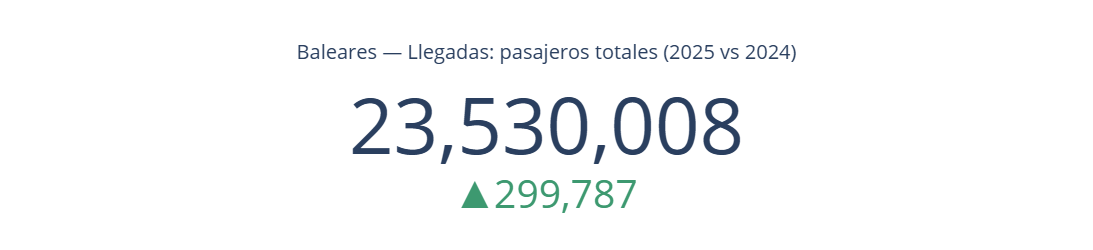

In [235]:
# Solo LLEGADAS
d = df_baleares[df_baleares["movimiento"] == "LLEGADA"].copy()

tot_2024 = d.loc[d["año"] == 2024, "pasajeros"].sum()
tot_2025 = d.loc[d["año"] == 2025, "pasajeros"].sum()

delta_abs = tot_2025 - tot_2024
delta_pct = (delta_abs / tot_2024 * 100) if tot_2024 else 0

fig_kpi = go.Figure(go.Indicator(
    mode="number+delta",
    value=tot_2025,
    number={"valueformat": ",.0f"},
    delta={
        "reference": tot_2024,
        "valueformat": ",.0f",
        "relative": False
    },
    title={"text": "Baleares — Llegadas: pasajeros totales (2025 vs 2024)"}
))

fig_kpi.update_layout(
    template="plotly_white",
    height=250,
    margin=dict(t=70, l=40, r=40, b=20)
)

fig_kpi.show()


### Visualización
Gráfico generado a partir del agregado definido en las celdas anteriores.

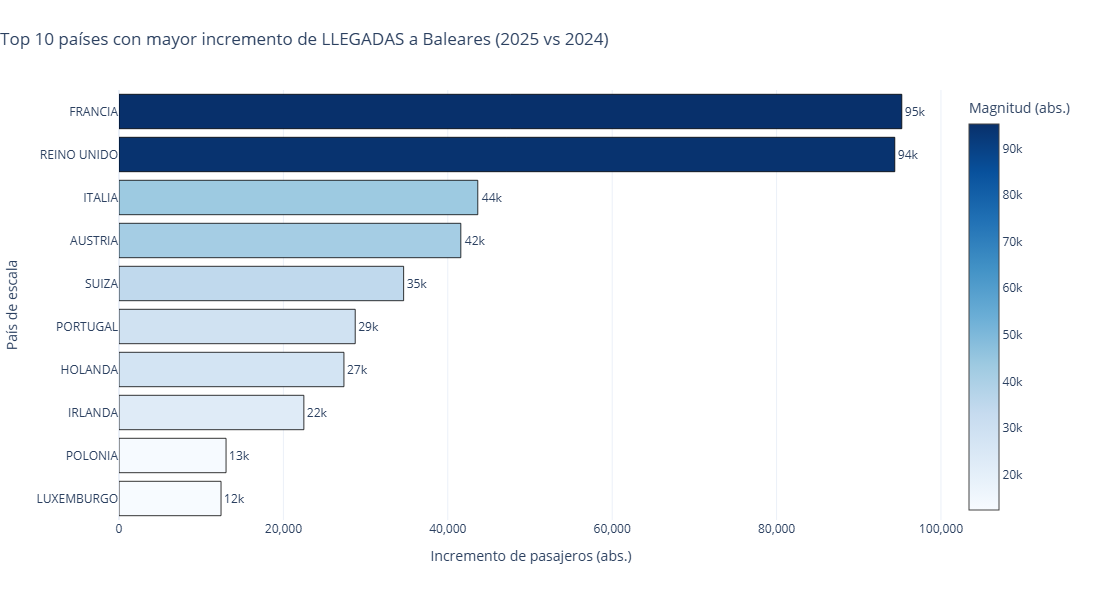

In [236]:
vals = top10_tbl["inc_abs"]
mag  = vals.abs()

fig_top = go.Figure()

fig_top.add_bar(
    y=top10_tbl["país"],
    x=vals,
    orientation="h",
    name="Incremento 2025 vs 2024",
    marker=dict(
        color=mag,
        colorscale="Blues",
        cmin=float(mag.min()),
        cmax=float(mag.max()),
        showscale=True,
        colorbar=dict(title="Magnitud (abs.)"),
        line=dict(color="black", width=0.8)
    ),
    texttemplate="%{x:.2s}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate="Incremento: %{x:,.0f}<extra></extra>"
)

fig_top.update_layout(
    title=dict(
        text="Top 10 países con mayor incremento de LLEGADAS a Baleares (2025 vs 2024)",
        x=0.0, xanchor="left"
    ),
    template="plotly_white",
    height=600,
    xaxis_title="Incremento de pasajeros (abs.)",
    yaxis_title="País de escala",
    margin=dict(t=90, r=90)
)

fig_top.update_xaxes(tickformat=",")
fig_top.update_yaxes(autorange="reversed")
fig_top.show()


### Visualización
Gráfico generado a partir del agregado definido en las celdas anteriores.

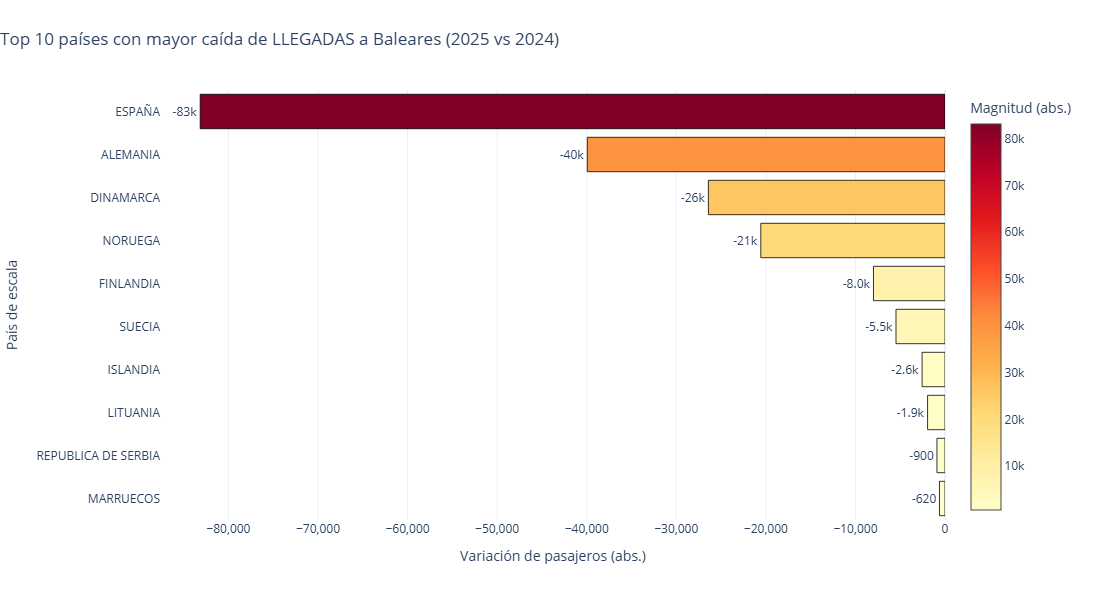

In [237]:
vals = top10_neg_tbl["var_abs"]
mag  = vals.abs()

fig_neg = go.Figure()

fig_neg.add_bar(
    y=top10_neg_tbl["país"],
    x=vals,
    orientation="h",
    name="Variación 2025 vs 2024",
    marker=dict(
        color=mag,
        colorscale="YlOrRd",
        cmin=float(mag.min()),
        cmax=float(mag.max()),
        showscale=True,
        colorbar=dict(title="Magnitud (abs.)"),
        line=dict(color="black", width=0.8)
    ),
    texttemplate="%{x:.2s}",
    textposition="outside",
    cliponaxis=False,
    hovertemplate="Variación: %{x:,.0f}<extra></extra>"
)

fig_neg.update_layout(
    title=dict(
        text="Top 10 países con mayor caída de LLEGADAS a Baleares (2025 vs 2024)",
        x=0.0,
        xanchor="left"
    ),
    template="plotly_white",
    height=600,
    xaxis_title="Variación de pasajeros (abs.)",
    yaxis_title="País de escala",
    margin=dict(t=90, r=90)
)

fig_neg.update_xaxes(tickformat=",")
fig_neg.update_yaxes(autorange="reversed")
fig_neg.show()


## 10. Visualización geográfica
Mapas basados en la lookup de aeropuertos (lkp_aeropuertos).

## 10. Visualización geográfica

En esta sección se asigna un **país** a cada aeropuerto de escala mediante la tabla `lkp_aeropuertos` y se generan mapas para:
- Aeropuertos de escala (puntos) por volumen de pasajeros.
- Países de escala (polígonos) por volumen y por variación 2025 vs 2024.

> Nota: los mapas se calculan con **LLEGADAS** (`df_baleares_llegadas`) y la métrica `pasajeros_totales`.

In [238]:
# Preparación de datos geográficos (lookup + agregados)

lkp = pd.read_excel(PATH_LKP, engine="openpyxl")
lkp.columns = lkp.columns.str.strip().str.lower().str.replace(" ", "_")

col_pais_lkp = "país" if "país" in lkp.columns else ("pais" if "pais" in lkp.columns else None)
if col_pais_lkp is None:
    raise KeyError(f"No encuentro columna 'pais/país' en lkp. Columnas: {list(lkp.columns)}")

col_country_en = "matched_country" if "matched_country" in lkp.columns else ("country_match" if "country_match" in lkp.columns else None)
if col_country_en is None:
    raise KeyError(f"No encuentro 'matched_country' en lkp. Columnas: {list(lkp.columns)}")

# Coordenadas
if ("lat" not in lkp.columns or "lon" not in lkp.columns):
    if "coordenadas" not in lkp.columns:
        raise KeyError("lkp_aeropuertos.xlsx debe tener 'lat'/'lon' o 'coordenadas'.")
    lkp[["lat", "lon"]] = (
        lkp["coordenadas"].astype(str)
        .str.split(",", n=1, expand=True)
        .apply(lambda c: pd.to_numeric(c.str.strip(), errors="coerce"))
    )

def en_to_iso3(name: str):
    try:
        return pycountry.countries.lookup(str(name)).alpha_3
    except Exception:
        return None

lkp_geo = (
    lkp[["aeropuerto_escala", col_pais_lkp, col_country_en, "lat", "lon"]]
    .rename(columns={col_pais_lkp: "pais_es", col_country_en: "pais_en"})
)
lkp_geo["iso3"] = lkp_geo["pais_en"].apply(en_to_iso3)

# Base: solo llegadas
d_geo = df_baleares_llegadas.copy()
d_geo["año"] = pd.to_numeric(d_geo["año"], errors="coerce").astype("Int64")
d_geo["pasajeros_totales"] = pd.to_numeric(d_geo["pasajeros_totales"], errors="coerce").fillna(0)

# Agregado por aeropuerto de escala
agg_airport = (
    d_geo[d_geo["año"].isin(YEARS)]
    .groupby(["año", "aeropuerto_escala"], as_index=False)["pasajeros_totales"]
    .sum()
)

agg_airport_geo = (
    agg_airport.merge(
        lkp_geo[["aeropuerto_escala", "pais_es", "iso3", "lat", "lon"]],
        on="aeropuerto_escala",
        how="left"
    )
    .dropna(subset=["iso3", "lat", "lon"])
)

# Agregado por país
agg_country = (
    agg_airport_geo.groupby(["año", "pais_es", "iso3"], as_index=False)["pasajeros_totales"]
    .sum()
)

total_year = agg_country.groupby("año")["pasajeros_totales"].transform("sum")
agg_country["pct_year"] = np.where(total_year > 0, agg_country["pasajeros_totales"] / total_year * 100, 0.0)

# Centroides aproximados por país (mediana de lat/lon de aeropuertos escala)
centroids = (
    lkp_geo.dropna(subset=["iso3", "lat", "lon"])
    .groupby(["pais_es", "iso3"], as_index=False)
    .agg(lat=("lat", "median"), lon=("lon", "median"))
)

# Variación % 2025 vs 2024 por país (sobre pasajeros totales)
piv = (
    agg_country.pivot(index=["pais_es", "iso3"], columns="año", values="pasajeros_totales")
    .fillna(0)
    .reset_index()
)
if 2024 not in piv.columns: piv[2024] = 0
if 2025 not in piv.columns: piv[2025] = 0

piv = piv.rename(columns={2024: "v2024", 2025: "v2025"})
piv["var_pct"] = np.where(piv["v2024"] > 0, (piv["v2025"] - piv["v2024"]) / piv["v2024"] * 100, np.nan)

var_country = piv.merge(centroids, on=["pais_es", "iso3"], how="left").dropna(subset=["lat", "lon"])


### 10.1 Aeropuertos de escala (puntos) — versión con filtro de volumen

Mapa de burbujas por **aeropuerto de escala**.

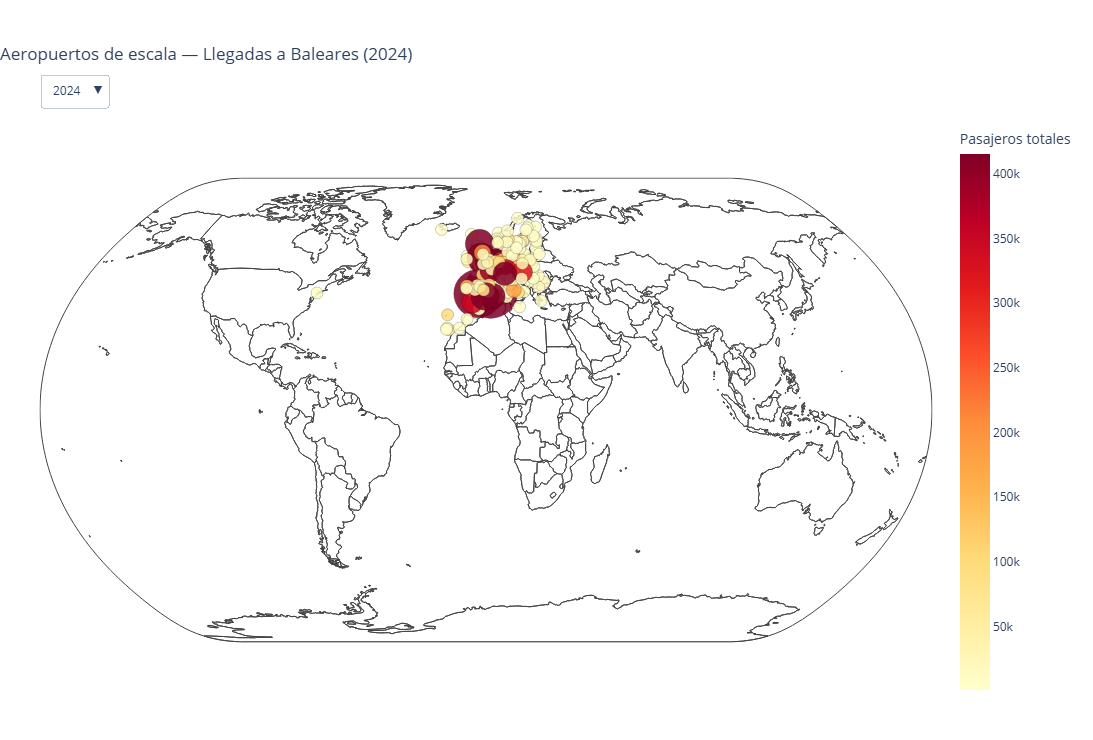

In [239]:
# Variante del mapa de burbujas: percentil + umbral mínimo

PCT_FILTER = 0.00
MIN_PAX = 300

# Tamaño máximo deseado (en px) para la burbuja más grande
MAX_BUBBLE_PX = 55
MIN_BUBBLE_PX = 6

pre2 = {}
for y in YEARS:
    sub = agg_airport_geo[agg_airport_geo["año"] == y].copy()
    if len(sub) == 0:
        pre2[y] = sub
        continue

    # 1) Filtro duro por año: eliminar aeropuertos con < 300 pasajeros en ESE año
    sub = sub[sub["pasajeros_totales"] >= MIN_PAX].copy()
    if len(sub) == 0:
        pre2[y] = sub
        continue

    # 2) Filtro por percentil (sobre los que ya superan MIN_PAX)
    p_filter = float(sub["pasajeros_totales"].quantile(PCT_FILTER))
    sub = sub[sub["pasajeros_totales"] >= p_filter].copy()
    if len(sub) == 0:
        pre2[y] = sub
        continue

    # Rango de color robusto
    cmin = float(sub["pasajeros_totales"].quantile(0.05))
    cmax = float(sub["pasajeros_totales"].quantile(0.95))
    if cmax <= cmin:
        cmin = float(sub["pasajeros_totales"].min())
        cmax = float(sub["pasajeros_totales"].max())

    sub["cmin"] = cmin
    sub["cmax"] = cmax

    # Tamaño: proporcional al volumen (monótono)
    # Con sizemode="area", Plotly interpreta "size" como área relativa (vía sizeref).
    sub["size"] = sub["pasajeros_totales"].astype(float)

    pre2[y] = sub

# sizeref GLOBAL para que el tamaño sea comparable entre años
all_sizes = [pre2[y]["size"].max() for y in YEARS if y in pre2 and len(pre2[y]) > 0]
global_max_size = max(all_sizes) if len(all_sizes) else 1.0
# Fórmula recomendada por Plotly para sizemode="area"
global_sizeref = 2.0 * global_max_size / (MAX_BUBBLE_PX ** 2)

y0 = YEARS[0]
sub0 = pre2.get(y0, pd.DataFrame())

fig2 = go.Figure()

if len(sub0) == 0:
    fig2.update_layout(
        title=dict(text=f"Aeropuertos de escala — Llegadas a Baleares ({y0})", x=0.0, xanchor="left"),
        template="plotly_white",
        height=720,
        margin=dict(t=90, l=40, r=40, b=40),
        geo=dict(scope="world", projection_type="natural earth", showcountries=True, showland=True)
    )
else:
    fig2.add_trace(go.Scattergeo(
        lon=sub0["lon"],
        lat=sub0["lat"],
        mode="markers",
        text=sub0["aeropuerto_escala"],
        customdata=np.c_[sub0["pais_es"], sub0["pasajeros_totales"]],
        marker=dict(
            size=sub0["size"],
            sizemode="area",
            sizeref=global_sizeref,     # <-- clave: escala global y coherente
            sizemin=MIN_BUBBLE_PX,
            color=sub0["pasajeros_totales"],
            colorscale="YlOrRd",
            cmin=float(sub0["cmin"].iloc[0]),
            cmax=float(sub0["cmax"].iloc[0]),
            showscale=True,
            colorbar=dict(title="Pasajeros totales"),
            line=dict(color="rgba(0,0,0,0.6)", width=0.4),
            opacity=0.85,
        ),
        hovertemplate=(
            "<b>%{text}</b><br>"
            "País: %{customdata[0]}<br>"
            "Pasajeros totales: <b>%{customdata[1]:,.0f}</b>"
            "<extra></extra>"
        ),
    ))

    buttons = []
    for y in YEARS:
        sub = pre2.get(y, pd.DataFrame())
        if len(sub) == 0:
            buttons.append(dict(
                label=str(y),
                method="update",
                args=[
                    {"lon": [[]], "lat": [[]], "marker.color": [[]], "marker.size": [[]]},
                    {"title.text": f"Aeropuertos de escala — Llegadas a Baleares ({y})"}
                ]
            ))
            continue

        buttons.append(dict(
            label=str(y),
            method="update",
            args=[
                {
                    "lon": [sub["lon"]],
                    "lat": [sub["lat"]],
                    "text": [sub["aeropuerto_escala"]],
                    "customdata": [np.c_[sub["pais_es"], sub["pasajeros_totales"]]],
                    "marker.size": [sub["size"]],
                    "marker.color": [sub["pasajeros_totales"]],
                    "marker.cmin": [float(sub["cmin"].iloc[0])],
                    "marker.cmax": [float(sub["cmax"].iloc[0])],
                    "marker.sizeref": [global_sizeref],  # <-- mantener escala igual
                    "marker.sizemin": [MIN_BUBBLE_PX],
                },
                {"title.text": f"Aeropuertos de escala — Llegadas a Baleares ({y})"}
            ]
        ))

    fig2.update_layout(
        title=dict(text=f"Aeropuertos de escala — Llegadas a Baleares ({y0})", x=0.0, xanchor="left"),
        template="plotly_white",
        height=740,
        margin=dict(t=120, l=40, r=40, b=40),
        updatemenus=[dict(
            buttons=buttons,
            direction="down",
            x=0.0, xanchor="left",
            y=1.08, yanchor="top",
            showactive=True
        )],
        geo=dict(scope="world", projection_type="natural earth", showcountries=True, showland=True),
    )

fig2.show()


### 10.3 Países de escala




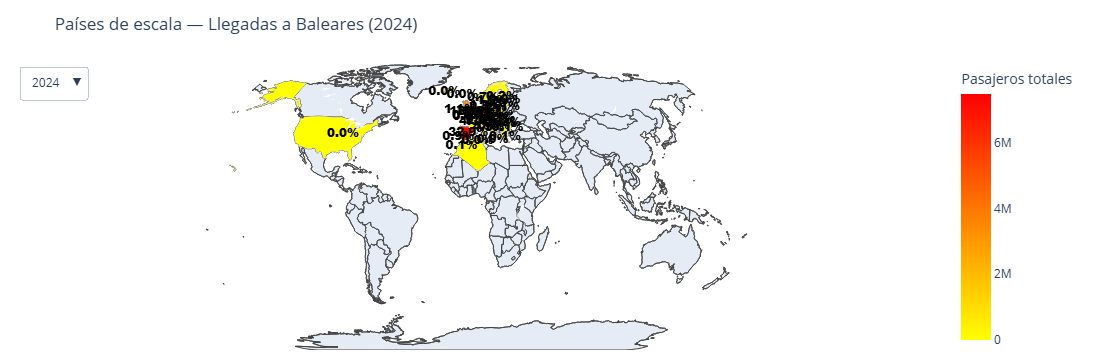

In [240]:
# Choropleth + etiquetas fijas (% del total anual)

MIN_PAX = 300
c = agg_country[agg_country["pasajeros_totales"] >= MIN_PAX].copy()

if len(c) == 0:
    figcl = go.Figure()
    figcl.update_layout(
        title=dict(text="Países de escala — Llegadas a Baleares (sin datos)", x=0.0, xanchor="left"),
        template="plotly_white"
    )
    figcl.show()
else:
    zmax = float(c["pasajeros_totales"].max())

    traces = []
    label_traces = []
    for i, y in enumerate(YEARS):
        sub = c[c["año"] == y].copy()
        lab = sub.merge(centroids, on=["pais_es", "iso3"], how="left").dropna(subset=["lat", "lon"]).reset_index(drop=True)

        traces.append(go.Choropleth(
            locations=sub["iso3"],
            locationmode="ISO-3",
            z=sub["pasajeros_totales"],
            zmin=0,
            zmax=zmax,
            colorscale=[[0.0, "yellow"], [1.0, "red"]],
            marker_line_color="white",
            marker_line_width=0.4,
            showscale=(i == 0),
            colorbar_title="Pasajeros totales",
            visible=(i == 0)
        ))

        label_traces.append(go.Scattergeo(
            lon=lab["lon"],
            lat=lab["lat"],
            mode="text",
            text=lab["pct_year"].map(lambda v: f"{v:.1f}%"),
            textposition="middle center",
            hoverinfo="skip",
            showlegend=False,
            visible=(i == 0),
            textfont=dict(size=12, color="black", family="Arial Black")
        ))

    figcl = go.Figure(traces + label_traces)

    buttons = []
    for i, y in enumerate(YEARS):
        vis = [False] * (2 * len(YEARS))
        vis[i] = True
        vis[i + len(YEARS)] = True
        buttons.append(dict(
            label=str(y),
            method="update",
            args=[{"visible": vis}, {"title": f"Países de escala — Llegadas a Baleares ({y})"}],
        ))

    figcl.update_layout(
        title=f"Países de escala — Llegadas a Baleares ({YEARS[0]})",
        updatemenus=[dict(type="dropdown", x=0.01, y=0.98, xanchor="left", yanchor="top", buttons=buttons)],
        geo=dict(showframe=False, showcountries=True, projection_type="natural earth"),
        margin=dict(l=10, r=10, t=60, b=10),
    )
    figcl.show()


### 10.5 Países de escala — variación % (2025 vs 2024)

Se pinta el país en verde si la variación es positiva y en rojo si es negativa.  
La etiqueta fija muestra la variación porcentual.


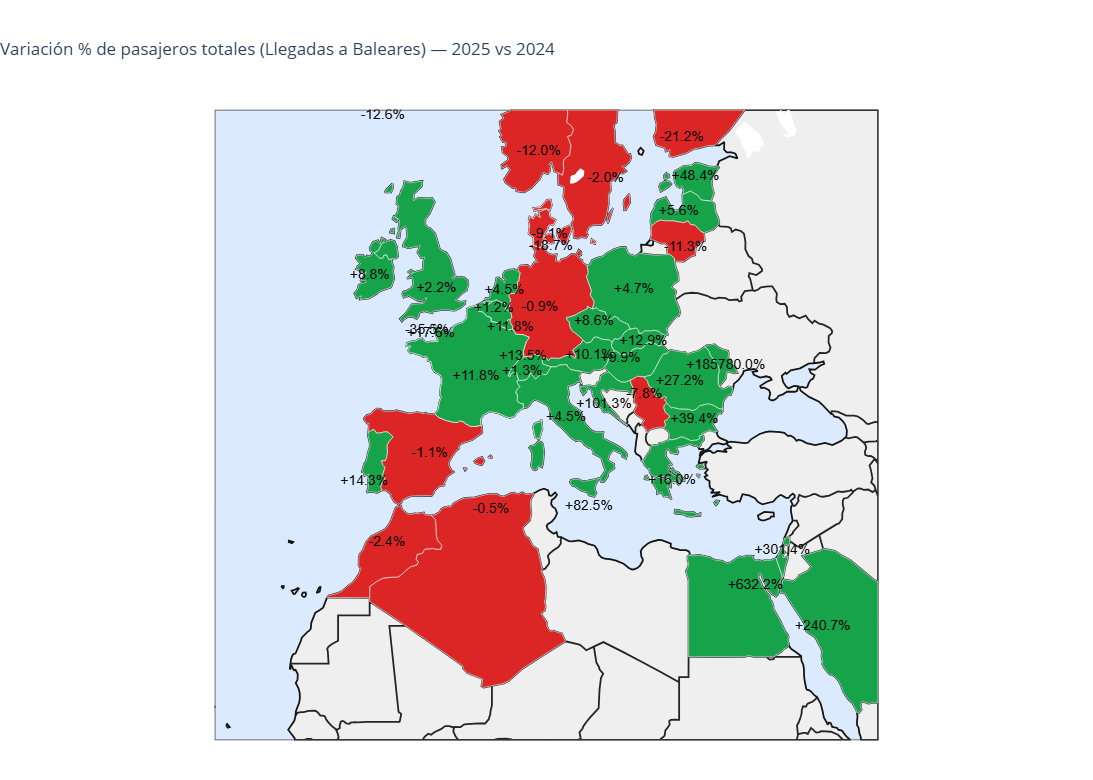

In [243]:
lkp = pd.read_excel("../data/lkp_aeropuertos.xlsx")
lkp.columns = lkp.columns.str.strip().str.lower().str.replace(" ", "_")

COL_PAIS_LKP = pick_col(lkp, ["pais", "país"])

# lat/lon desde columnas o desde "coordenadas"
if ("lat" not in lkp.columns or "lon" not in lkp.columns):
    if "coordenadas" not in lkp.columns:
        raise KeyError("lkp_aeropuertos.xlsx debe tener 'lat'/'lon' o 'coordenadas'.")
    lkp[["lat", "lon"]] = (
        lkp["coordenadas"]
        .astype(str)
        .str.split(",", n=1, expand=True)
        .apply(lambda c: pd.to_numeric(c.str.strip(), errors="coerce"))
    )

COL_COUNTRY_EN = pick_col(lkp, ["matched_country", "country_match"])

def en_to_iso3(x):
    try:
        return pycountry.countries.lookup(str(x)).alpha_3
    except Exception:
        return None

lkp_small = (
    lkp[["aeropuerto_escala", COL_PAIS_LKP, COL_COUNTRY_EN, "lat", "lon"]]
    .rename(columns={COL_PAIS_LKP: "pais", COL_COUNTRY_EN: "pais_en"})
)
lkp_small["iso3"] = lkp_small["pais_en"].apply(en_to_iso3)

# =========================
# 2) Base AENA (LLEGADAS)
# =========================
d = df_baleares_llegadas.copy()

COL_ESCALA = pick_col(d, ["aeropuerto_escala"])
COL_DATE   = pick_col(d, ["fecha"])
COL_MET    = pick_col(d, ["pasajeros_totales"])

d[COL_DATE] = pd.to_datetime(d[COL_DATE], errors="coerce")
d[COL_MET]  = pd.to_numeric(d[COL_MET], errors="coerce").fillna(0)
d = d.dropna(subset=[COL_DATE]).copy()

d["año"] = d[COL_DATE].dt.year
d = d[d["año"].isin([2024, 2025])].copy()

df = d.merge(
    lkp_small,
    on="aeropuerto_escala",
    how="left",
    validate="many_to_one"
)
df = df.dropna(subset=["pais", "iso3"]).copy()

# =========================
# 3) Agregar por país y año (2024 / 2025) y calcular variación %
# =========================
g = (
    df.groupby(["pais", "iso3", "año"], as_index=False)[COL_MET]
      .sum()
      .rename(columns={COL_MET: "pasajeros_totales"})
)

p = (
    g.pivot(index=["pais", "iso3"], columns="año", values="pasajeros_totales")
     .fillna(0)
     .reset_index()
)
p.columns.name = None

# asegurar columnas 2024 y 2025
if 2024 not in p.columns: p[2024] = 0
if 2025 not in p.columns: p[2025] = 0

p = p.rename(columns={2024: "v2024", 2025: "v2025"})

# Variación % 2025 vs 2024
p["var_pct"] = np.where(
    p["v2024"] > 0,
    (p["v2025"] - p["v2024"]) / p["v2024"] * 100,
    np.nan
)

# quitamos países donde la variación no está definida
p = p.dropna(subset=["var_pct"]).copy()

# =========================
# 4) Coordenadas por país (centroide proxy)
# =========================
country_xy = (
    lkp_small.dropna(subset=["lat", "lon"])
             .groupby(["pais", "iso3"], as_index=False)
             .agg(lat=("lat", "median"), lon=("lon", "median"))
)

m = p.merge(country_xy, on=["pais", "iso3"], how="left")
m = m.dropna(subset=["lat", "lon"]).copy()

# opcional: filtro por volumen mínimo en 2025
MIN_PAS_2025 = 300
m = m[m["v2025"] >= MIN_PAS_2025].copy()

# =========================
# 5) Color binario por signo de la variación
#     z =  1 → crecimiento (verde)
#     z = -1 → caída (rojo)
# =========================
m["z_sign"] = np.where(m["var_pct"] >= 0, 1, -1)

# =========================
# 6) Choropleth + etiquetas fijas con la variación %
# =========================
fig = go.Figure()

# 6a) Choropleth (país completo)
fig.add_trace(go.Choropleth(
    locations=m["iso3"],
    locationmode="ISO-3",
    z=m["z_sign"],
    zmin=-1,
    zmax=1,
    colorscale=[
        [0.0, "#DC2626"],   # rojo (negativo)
        [0.5, "#DC2626"],
        [0.5, "#16A34A"],   # verde (positivo)
        [1.0, "#16A34A"],
    ],
    marker_line_color="white",
    marker_line_width=0.6,
    customdata=np.c_[m["pais"], m["v2024"], m["v2025"], m["var_pct"]],
    hovertemplate=(
        "<b>%{customdata[0]}</b><br>"
        "2024: <b>%{customdata[1]:,.0f}</b><br>"
        "2025: <b>%{customdata[2]:,.0f}</b><br>"
        "Variación % 2025 vs 2024: <b>%{customdata[3]:.2f}%</b>"
        "<extra></extra>"
    ),
    showscale=False
))



# 6c) Etiquetas fijas: variación % (texto blanco)
fig.add_trace(go.Scattergeo(
    lon=m["lon"],
    lat=m["lat"],
    mode="text",
    text=m["var_pct"].map(lambda v: f"{v:+.1f}%"),
    textposition="middle center",
    hoverinfo="skip",
    showlegend=False,
    textfont=dict(size=14, color="black", family="Arial"),
))

# =========================
# 7) Layout
# =========================
fig.update_layout(
    title=dict(
        text="Variación % de pasajeros totales (Llegadas a Baleares) — 2025 vs 2024",
        x=0.0, xanchor="left"
    ),
    template="plotly_white",
    height=780,
    margin=dict(t=110, l=40, r=40, b=40),
    geo=dict(
        scope="world",
        projection_type="mercator",
        showland=True, landcolor="#EFEFEF",
        showocean=True, oceancolor="#DBEAFE",
        showcountries=True,
        countrycolor="rgba(0,0,0,0.85)",
        countrywidth=1.8,
        showcoastlines=True,
        coastlinecolor="rgba(0,0,0,0.55)",
        coastlinewidth=1.0,
        bgcolor="white",
        lataxis=dict(range=[20, 65]),
        lonaxis=dict(range=[-25, 45]),
    )
)

fig.show()


### 10.6 Redes de escalas hacia baleares - 2025 - Por isla

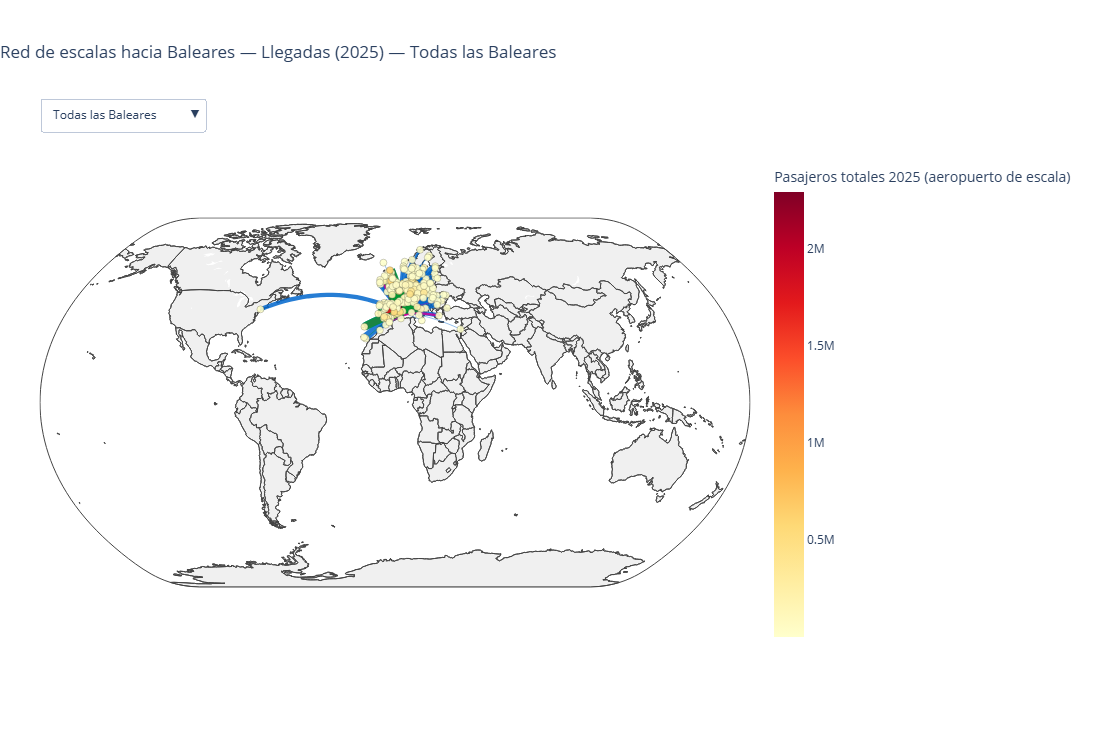

In [246]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# =========================
# Parámetros
# =========================
YEAR = 2025

# Filtros
MIN_PAX_ROUTE = 500          # mínimo por ruta (escala->base) en 2025
MIN_PAX_NODE  = 500          # mínimo por nodo (aeropuerto_escala) en 2025

# Curvatura y visual
N_CURVE = 25
MAP_HEIGHT = 740
N_WIDTH_BINS = 6
LINE_W_MIN, LINE_W_MAX = 0.5, 10.0

# Colores por aeropuerto_base
BASE_COLORS = {
    "PALMA DE MALLORCA": "rgba(0, 102, 204, 0.85)",  # azul fuerte
    "IBIZA": "rgba(204, 0, 153, 0.85)",              # magenta fuerte
    "MENORCA": "rgba(0, 153, 51, 0.85)",             # verde fuerte
}

BALEARES = ["PALMA DE MALLORCA", "IBIZA", "MENORCA"]

# =========================
# Utils
# =========================
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"No encuentro ninguna de estas columnas: {candidates}")

def great_circle_points(lat1, lon1, lat2, lon2, n=25):
    lat1, lon1, lat2, lon2 = map(np.deg2rad, [lat1, lon1, lat2, lon2])

    def to_xyz(lat, lon):
        return np.array([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)])

    p1 = to_xyz(lat1, lon1)
    p2 = to_xyz(lat2, lon2)

    omega = np.arccos(np.clip(np.dot(p1, p2), -1.0, 1.0))
    if np.isclose(omega, 0):
        lats = np.linspace(np.rad2deg(lat1), np.rad2deg(lat2), n)
        lons = np.linspace(np.rad2deg(lon1), np.rad2deg(lon2), n)
        return lats, lons

    sin_omega = np.sin(omega)
    ts = np.linspace(0, 1, n)

    pts = []
    for t in ts:
        a = np.sin((1 - t) * omega) / sin_omega
        b = np.sin(t * omega) / sin_omega
        p = a * p1 + b * p2
        p = p / np.linalg.norm(p)
        pts.append(p)

    pts = np.vstack(pts)
    lats = np.rad2deg(np.arcsin(pts[:, 2]))
    lons = np.rad2deg(np.arctan2(pts[:, 1], pts[:, 0]))
    return lats, lons

def width_from_bins(values, wmin=1.0, wmax=11.0, n_bins=6):
    v = pd.Series(values).astype(float)

    if len(v) == 0:
        return pd.Series(dtype=int), np.array([])

    if v.nunique() < 3:
        widths = np.full(len(v), (wmin + wmax) / 2)
        return pd.Series([0] * len(v)), widths

    bins = pd.qcut(v, q=min(n_bins, v.nunique()), duplicates="drop")
    codes = bins.cat.codes
    k = int(codes.max() + 1)

    if k <= 1:
        widths = np.full(len(v), (wmin + wmax) / 2)
    else:
        widths = wmin + (codes.to_numpy() / (k - 1)) * (wmax - wmin)

    return codes, widths

# =========================
# 1) Lookup aeropuertos (coords)
# =========================
lkp = pd.read_excel("../data/lkp_aeropuertos.xlsx")
lkp.columns = lkp.columns.str.strip().str.lower().str.replace(" ", "_")

COL_LAT = pick_col(lkp, ["lat", "latitude"])
COL_LON = pick_col(lkp, ["lon", "longitude"])
COL_PAIS = pick_col(lkp, ["país", "pais"])

if (COL_LAT not in lkp.columns or COL_LON not in lkp.columns) and "coordenadas" in lkp.columns:
    lkp[[COL_LAT, COL_LON]] = (
        lkp["coordenadas"].astype(str)
        .str.split(",", n=1, expand=True)
        .apply(lambda c: pd.to_numeric(c.str.strip(), errors="coerce"))
    )

lkp_geo = (
    lkp[["aeropuerto_escala", COL_PAIS, COL_LAT, COL_LON]]
    .rename(columns={COL_PAIS: "pais_es", COL_LAT: "lat", COL_LON: "lon"})
    .dropna(subset=["lat", "lon"])
    .copy()
)

# =========================
# 2) Base AENA (LLEGADAS) — año fijo 2025
# =========================
d = df_baleares_llegadas.copy()

COL_ESCALA = pick_col(d, ["aeropuerto_escala"])
COL_BASE   = pick_col(d, ["aeropuerto_base"])
COL_YEAR   = pick_col(d, ["año"])
COL_MET    = pick_col(d, ["pasajeros_totales"])

d[COL_YEAR] = pd.to_numeric(d[COL_YEAR], errors="coerce").astype("Int64")
d[COL_MET]  = pd.to_numeric(d[COL_MET], errors="coerce").fillna(0)

d = d[(d[COL_YEAR] == YEAR) & (d[COL_BASE].isin(BALEARES))].copy()

# NODOS 2025: aeropuerto_escala -> suma pax
nodes = (
    d.groupby([COL_ESCALA], as_index=False)[COL_MET]
     .sum()
     .rename(columns={COL_ESCALA: "aeropuerto_escala", COL_MET: "pasajeros_totales"})
).merge(lkp_geo, on="aeropuerto_escala", how="left")

nodes = nodes.dropna(subset=["lat", "lon"]).copy()
nodes = nodes[nodes["pasajeros_totales"] >= MIN_PAX_NODE].copy()

# RUTAS 2025: (aeropuerto_escala, aeropuerto_base) -> suma pax
routes = (
    d.groupby([COL_ESCALA, COL_BASE], as_index=False)[COL_MET]
     .sum()
     .rename(columns={COL_ESCALA: "aeropuerto_escala", COL_BASE: "aeropuerto_base", COL_MET: "pasajeros_totales"})
)
routes = routes[routes["pasajeros_totales"] >= MIN_PAX_ROUTE].copy()
routes = routes.merge(lkp_geo[["aeropuerto_escala", "lat", "lon", "pais_es"]], on="aeropuerto_escala", how="left")

# Coordenadas Baleares (fallback)
fallback_baleares = {
    "PALMA DE MALLORCA": (39.5517, 2.7388),
    "IBIZA": (38.8729, 1.3731),
    "MENORCA": (39.8626, 4.2186),
}
base_geo = pd.DataFrame([{"aeropuerto_base": k, "lat_base": v[0], "lon_base": v[1]} for k, v in fallback_baleares.items()])
routes = routes.merge(base_geo, on="aeropuerto_base", how="left")
routes = routes.dropna(subset=["lat", "lon", "lat_base", "lon_base"]).copy()

# =========================
# 3) Construir figura con dropdown por aeropuerto_base
# =========================
fig = go.Figure()

# Vamos a crear 4 "vistas":
# - ALL (todas las bases)
# - Palma
# - Ibiza
# - Menorca
VIEWS = ["TODAS"] + BALEARES

trace_groups = []  # índices de trazas por vista
all_trace_idxs = []  # por si querés referenciarlas

# Helper: añade líneas por bins para un subconjunto routes
def add_lines_for_routes(r_sub, color_rgba, visible):
    idxs = []
    if len(r_sub) == 0:
        return idxs

    bin_id, widths = width_from_bins(
        r_sub["pasajeros_totales"],
        wmin=LINE_W_MIN,
        wmax=LINE_W_MAX,
        n_bins=N_WIDTH_BINS
    )
    r_sub = r_sub.copy()
    r_sub["bin"] = bin_id
    r_sub["width"] = widths

    # bins de menor->mayor para que las líneas gruesas queden arriba
    for b in sorted(r_sub["bin"].dropna().unique()):
        rbb = r_sub[r_sub["bin"] == b].copy()
        if len(rbb) == 0:
            continue
        w_bin = float(rbb["width"].median())

        lons_bin, lats_bin = [], []
        for _, row in rbb.iterrows():
            lats, lons = great_circle_points(row["lat"], row["lon"], row["lat_base"], row["lon_base"], n=N_CURVE)
            lats_bin.extend(list(lats) + [None])
            lons_bin.extend(list(lons) + [None])

        fig.add_trace(go.Scattergeo(
            lon=lons_bin,
            lat=lats_bin,
            mode="lines",
            line=dict(width=w_bin, color=color_rgba),
            hoverinfo="skip",
            showlegend=False,
            visible=visible,
        ))
        idxs.append(len(fig.data) - 1)

    return idxs

# Helper: puntos (mismos para todas las vistas)
def add_nodes_points(visible):
    fig.add_trace(go.Scattergeo(
        lon=nodes["lon"],
        lat=nodes["lat"],
        mode="markers",
        text=nodes["aeropuerto_escala"],
        customdata=np.c_[nodes["pais_es"], nodes["pasajeros_totales"]],
        marker=dict(
            size=7,
            color=nodes["pasajeros_totales"],
            colorscale="YlOrRd",
            showscale=True,  # una sola vez (la primera vista será visible)
            colorbar=dict(
                title="Pasajeros totales 2025 (aeropuerto de escala)",
                x=1.02,
                len=0.85
            ),
            line=dict(color="rgba(0,0,0,0.55)", width=0.4),
            opacity=0.9,
        ),
        hovertemplate=(
            "<b>%{text}</b><br>"
            "País: %{customdata[0]}<br>"
            "Pasajeros totales 2025: <b>%{customdata[1]:,.0f}</b>"
            "<extra></extra>"
        ),
        showlegend=False,
        visible=visible,
    ))
    return [len(fig.data) - 1]

# --- Vista 0: TODAS
idxs_all = []
for base in BALEARES:
    idxs_all += add_lines_for_routes(
        routes[routes["aeropuerto_base"] == base],
        BASE_COLORS.get(base, "rgba(0,0,0,0.4)"),
        visible=True
    )
idxs_all += add_nodes_points(visible=True)
trace_groups.append(idxs_all)

# --- Vistas individuales por base
for base in BALEARES:
    idxs = []
    idxs += add_lines_for_routes(
        routes[routes["aeropuerto_base"] == base],
        BASE_COLORS.get(base, "rgba(0,0,0,0.4)"),
        visible=False
    )
    # puntos se mantienen (pero sin repetir colorbar: la ocultamos)
    fig.add_trace(go.Scattergeo(
        lon=nodes["lon"],
        lat=nodes["lat"],
        mode="markers",
        text=nodes["aeropuerto_escala"],
        customdata=np.c_[nodes["pais_es"], nodes["pasajeros_totales"]],
        marker=dict(
            size=7,
            color=nodes["pasajeros_totales"],
            colorscale="YlOrRd",
            showscale=False,  # no repetir colorbar
            line=dict(color="rgba(0,0,0,0.55)", width=0.4),
            opacity=0.9,
        ),
        hovertemplate=(
            "<b>%{text}</b><br>"
            "País: %{customdata[0]}<br>"
            "Pasajeros totales 2025: <b>%{customdata[1]:,.0f}</b>"
            "<extra></extra>"
        ),
        showlegend=False,
        visible=False,
    ))
    idxs.append(len(fig.data) - 1)

    trace_groups.append(idxs)

# --- Dropdown por aeropuerto_base
buttons = []
for i, view in enumerate(VIEWS):
    vis = [False] * len(fig.data)
    for j in trace_groups[i]:
        vis[j] = True
    label = "Todas las Baleares" if view == "TODAS" else view
    buttons.append(dict(
        label=label,
        method="update",
        args=[
            {"visible": vis},
            {"title.text": f"Red de escalas hacia Baleares — Llegadas (2025) — {label}"}
        ]
    ))

# =========================
# Layout (mapa grande + título visible)
# =========================
fig.update_layout(
    title=dict(
        text="Red de escalas hacia Baleares — Llegadas (2025) — Todas las Baleares",
        x=0.0, xanchor="left"
    ),
    template="plotly_white",
    height=MAP_HEIGHT,
    margin=dict(t=115, l=40, r=140, b=50),
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        x=0.0, xanchor="left",
        y=1.03, yanchor="top",
        showactive=True
    )],
    geo=dict(
        scope="world",
        projection_type="natural earth",
        showcountries=True,
        showland=True,
        landcolor="rgb(240,240,240)",
        domain=dict(x=[0.0, 1.0], y=[0.0, 1.0]),
    ),
)

fig.show()
